# Data Analytics  - Injection Molding

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


In [ ]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler, RobustScaler, PolynomialFeatures, SplineTransformer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_val_score, KFold
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import roc_auc_score

import shap
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, roc_auc_score



In [ ]:
#Run if Dataset has been uploaded manually in the Google Drive
inj_pd = pd.read_csv('injection_modeling.csv')

In [ ]:
#Run to get the dataset via Shared Google Drive Folder
inj_pd = pd.read_csv('/content/drive/MyDrive/1. Projects(단기)/DAEM/Injection Data/injection_modeling.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/1. Projects(단기)/DAEM/Injection Data/injection_modeling.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Understanding of the Data

## Context and Motivation

Goal: Predict Weight (Continuos)
- Possibly classify normal vs defective
- Based on Machine CV/SV


Purpose of Analysis

To predict and prevent equipment malfunctions and quality defects in the injection molding process by monitoring machine parameters. This analysis aims to identify early warning signals and establish data-driven maintenance schedules.

Problem Definition

Manual monitoring of machine status often leads to delayed detection of faults and unexpected downtime.

Therefore, we seek to answer:
- What insigts we can defer from the current state of the dataset?
- Which Machine Learning Methods be effective in detecting defects given this dataset?
- Which Features influence the Machine Learning Methods' decision to determine defects?

The goal is to build a machine learning model that can monitor equipment health, detect anomalies, and predict possible failures before they occur.

##General Information

In [ ]:
inj_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1323 entries, 0 to 1322
Data columns (total 71 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   INJ_ID          1323 non-null   float64
 1   INJ_NO          1323 non-null   int64  
 2   SPC_DATETIME    1323 non-null   object 
 3   PROC_QTY        1323 non-null   float64
 4   CV_001          1323 non-null   float64
 5   CV_002          1323 non-null   float64
 6   CV_003          1323 non-null   float64
 7   CV_004          1323 non-null   float64
 8   CV_005          1323 non-null   float64
 9   CV_006          1323 non-null   float64
 10  CV_007          1323 non-null   float64
 11  CV_013          1323 non-null   float64
 12  CV_014          1323 non-null   float64
 13  CV_015          1323 non-null   float64
 14  CV_016          1323 non-null   float64
 15  CV_017          1323 non-null   float64
 16  CV_018          1323 non-null   float64
 17  CV_019          1323 non-null   f

The dataset contains 1323 observations (rows) and 71 variables (columns).

---



Data types:

*   Float64: 25 columns (continuous sensor measurements — e.g., pressures, temperatures, weights)
*   Int64: 44 columns (mostly setpoint or count-type parameters)

*   Object: 2 columns — likely categorical or timestamp-type (SPC_DATETIME, stock_mst_code)

No missing values are reported (1323 non-null for all columns).

In [ ]:
inj_pd.describe()

,INJ_ID,INJ_NO,PROC_QTY,CV_001,CV_002,CV_003,CV_004,CV_005,CV_006,CV_007,...,SV_051,SV_055,SV_056,SV_057,SV_058,SV_059,SV_060,SV_063,MOLD_CAVITY,weight
count,1.323000e+03,1323.0,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,...,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000,1323.000000
mean,2.711478e+06,12.0,940.158266,65.701464,344.087337,11.698807,3.195214,1.460148,25.400575,207.391075,...,207.369796,1.936508,3.515495,2.830688,19.909297,44.735450,36.953893,41.148148,0.584278,1091.391845
std,2.481956e+04,0.0,463.129134,16.647290,81.241143,4.666949,6.000345,2.276208,16.415698,98.500426,...,98.523575,1.667221,1.841370,9.546212,22.363878,62.987928,38.622501,10.772681,0.493032,703.879692
min,2.678317e+06,12.0,8.000000,45.400000,223.300000,5.000000,0.000000,0.000000,6.300000,81.000000,...,81.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000,347.700000
25%,2.689780e+06,12.0,747.170425,48.550000,268.697684,8.300000,0.000000,0.000000,9.700000,102.100000,...,102.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,32.000000,0.000000,488.287604
50%,2.706558e+06,12.0,890.574148,66.800000,313.088912,11.100000,0.000000,0.200000,21.801976,190.099542,...,190.000000,2.000000,3.000000,0.000000,0.000000,0.000000,50.000000,42.000000,1.000000,905.431663
75%,2.734213e+06,12.0,1195.375781,77.668501,401.892083,14.100000,0.101566,2.300000,41.150000,301.994847,...,302.000000,2.000000,6.000000,0.000000,50.000000,140.000000,50.000000,50.000000,1.000000,1527.150000
max,2.765857e+06,12.0,2499.000000,161.700000,595.100000,24.000000,15.000000,8.700000,70.900000,411.900000,...,412.000000,6.000000,6.000000,35.000000,50.000000,140.000000,100.000000,95.000000,1.000000,3205.200000


The dataset includes 69 numerical variables describing process and equipment parameters for 1323 production cycles.

---



**Key observations**:

* INJ_NO is constant (always 12) → not informative for analysis.

* PROC_QTY (processed quantity) ranges from 8 to 2499, showing a wide variation in production volume per cycle.

* CV_001–CV_020 and SV_001–SV_063 represent continuous and setpoint variables (e.g., pressures, temperatures, timings).

* Several SV_* columns contain many zeros, possibly representing parameters that were not active or not recorded in certain runs.

* Weight varies significantly — from ~347.7 to 3205.2, with an average around 1091 and a standard deviation of 703.8. This high variability could indicate differences in mold type, material, or process conditions.

In [ ]:
inj_pd.isnull().sum()

,0
INJ_ID,0
INJ_NO,0
SPC_DATETIME,0
PROC_QTY,0
CV_001,0
...,...
SV_060,0
SV_063,0
MOLD_CAVITY,0
stock_mst_code,0


All 71 columns contain 0 missing values

##General EDA of the Dataset

/tmp/ipython-input-3679325382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=inj_pd, x='stock_mst_code', palette="crest")


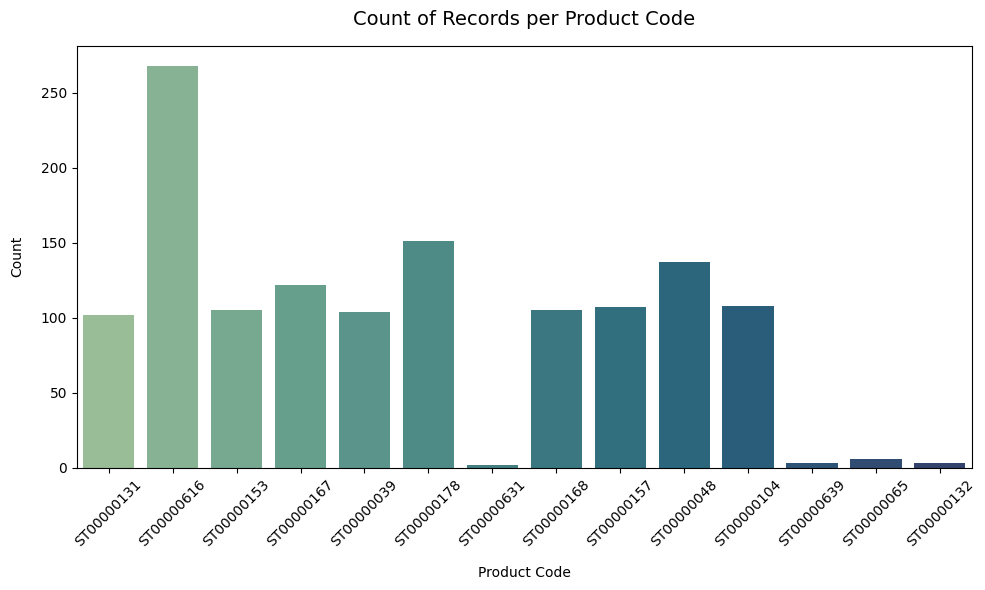

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=inj_pd, x='stock_mst_code', palette="crest")
plt.title("Count of Records per Product Code", fontsize=14, pad=15)
plt.xlabel("Product Code", labelpad=12)
plt.ylabel("Count", labelpad=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


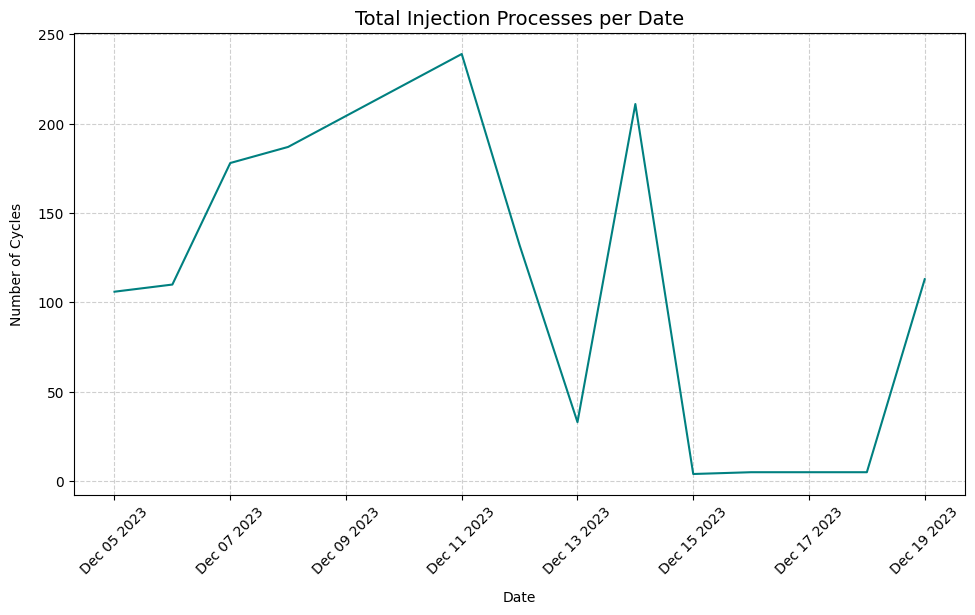

In [ ]:
inj_pd['SPC_DATETIME'] = pd.to_datetime(inj_pd['SPC_DATETIME'])
process_per_day = inj_pd.groupby(inj_pd['SPC_DATETIME'].dt.date).size()

plt.figure(figsize=(11.5,6))
process_per_day.plot(kind='line', color='teal')
plt.title('Total Injection Processes per Date', fontsize=14)
plt.xlabel('Date', labelpad=10)
plt.ylabel('Number of Cycles', labelpad=10)
plt.tick_params(axis='x', rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d %Y'))

plt.show()

/tmp/ipython-input-3904564538.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=inj_pd, x='MOLD_CAVITY', palette='crest')
/tmp/ipython-input-3904564538.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=inj_pd, x='MOLD_CAVITY', y='weight', palette="crest")


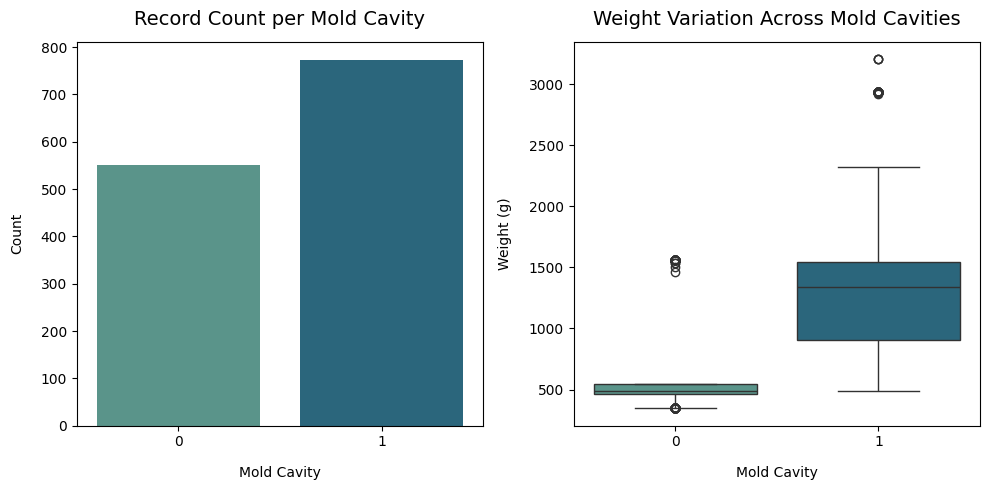

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(data=inj_pd, x='MOLD_CAVITY', palette='crest')
plt.title("Record Count per Mold Cavity", fontsize=14, pad=12)
plt.xlabel("Mold Cavity", labelpad=12)
plt.ylabel("Count", labelpad=12)


plt.subplot(1,2,2)
sns.boxplot(data=inj_pd, x='MOLD_CAVITY', y='weight', palette="crest")
plt.title("Weight Variation Across Mold Cavities", fontsize=14, pad=12)
plt.xlabel("Mold Cavity", labelpad=12)
plt.ylabel("Weight (g)", labelpad=12)


plt.tight_layout()
plt.show()


# Target Variable: Defect Flag
### Defect Flag is not explicitly in the Dataset. Howerver. the defect flag is based on the Weight Distribution of the Products



**Product Type Analysis**

In [ ]:
# data preprocessing 1.
# When checking by product, it is reasonable to exclude data with fewer than 10 samples, as such a small amount of data is not suitable for modeling.
inj_pd.groupby('stock_mst_code')['weight'].describe()

,count,mean,std,min,25%,50%,75%,max
stock_mst_code,,,,,,,,
ST00000039,104.0,488.252603,0.261839,486.1,488.290306,488.293580,488.296853,488.3
ST00000048,137.0,1541.528879,8.630263,1517.7,1538.500000,1545.950421,1546.483043,1547.0
ST00000065,6.0,599.883333,6.587994,594.3,595.900000,598.300000,600.250000,612.4
ST00000104,108.0,349.600438,0.370162,347.7,349.573709,349.583181,349.592653,352.3
ST00000131,102.0,2936.696944,1.353382,2923.2,2936.741595,2936.828882,2936.916170,2937.0
ST00000132,3.0,3203.666667,1.361372,3202.6,3202.900000,3203.200000,3204.200000,3205.2
ST00000153,105.0,1556.507940,11.072938,1462.6,1557.450968,1558.311680,1559.172392,1560.0
ST00000157,107.0,541.567200,0.532988,541.4,541.420557,541.441919,541.463282,544.4
ST00000167,122.0,485.605677,2.664203,479.1,484.934334,484.961268,484.988202,499.3


Each product type (stock_mst_code) shows a distinct average weight and variation:

* Mean weights range from around 350 g to over 2900 g, reflecting differences in product size or mold type.

* Products such as ST0000131 and ST0000132 have significantly higher weights, while ST0000039 and ST0000104 are much lighter.

* Some codes (e.g., ST0000065, ST0000631, ST0000639) have fewer than 10 samples — these were excluded from further modeling to ensure statistical reliability.

/tmp/ipython-input-1060122139.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='stock_mst_code', y='cv', data=cv_df, palette='viridis')


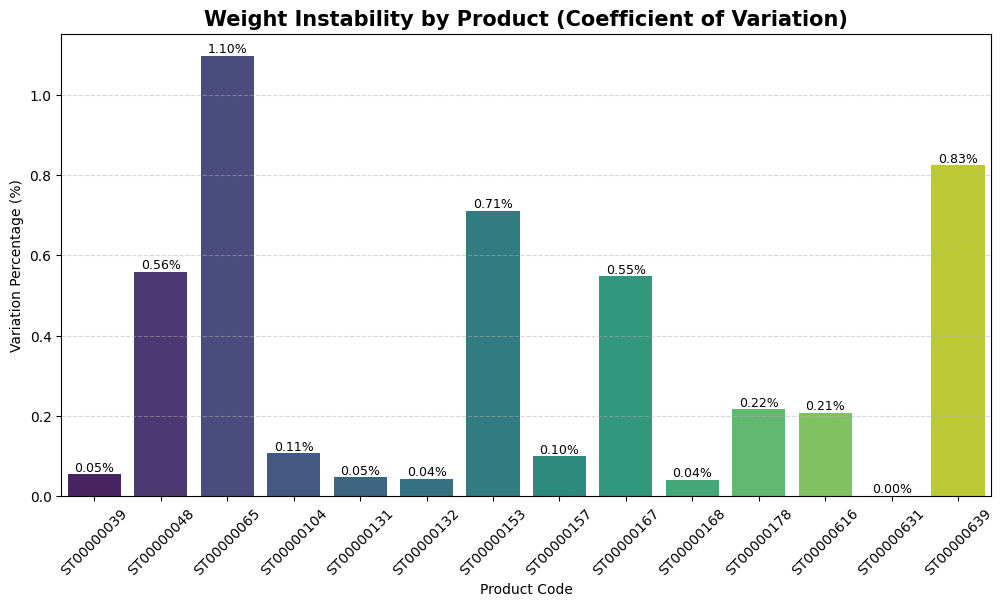

In [ ]:
cv_df = inj_pd.groupby('stock_mst_code')['weight'].apply(lambda x: (x.std() / x.mean()) * 100).reset_index()
cv_df.columns = ['stock_mst_code', 'cv']

plt.figure(figsize=(12, 6))
sns.barplot(x='stock_mst_code', y='cv', data=cv_df, palette='viridis')

plt.title('Weight Instability by Product (Coefficient of Variation)', fontsize=15, fontweight='bold')
plt.ylabel('Variation Percentage (%)')
plt.xlabel('Product Code')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(cv_df['cv']):
    plt.text(i, v, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)

plt.show()

Observation: While most products maintain stable quality (CV < 0.2%), Product ST00000065 (1.10%) and ST00000048 (0.56%) exhibit significantly higher instability.

Conclusion: This disparity in process stability necessitates robust data preprocessing to prevent model bias towards unstable products.

## 1. Calculating for the Defect Flag: Product-wise Weight Distribution
Each product type (defined by stock_mst_code) shows a distinct weight distribution, likely due to differences in mold size or design.

Products with fewer than 10 samples were removed to keep the analysis statistically reliable.

The following sections compare the weight and process parameters across the remaining product groups.

In [ ]:
#Data with fewer than 10 samples were excluded.
inj_pd = (
    inj_pd.groupby("stock_mst_code")
      .filter(lambda x: len(x) >= 10))

In [ ]:
#Product-wise weight statistics
stats = inj_pd.groupby('stock_mst_code')['weight'].agg(['mean','std','count']).reset_index()

#defect classification using statistical methods
inj_pd = inj_pd.merge(stats, on='stock_mst_code', how='left')

#labeling(normal/outlier)
inj_pd['UCL'] = inj_pd['mean'] + 2*inj_pd['std']
inj_pd['LCL'] = inj_pd['mean'] - 2*inj_pd['std']

inj_pd['defect_flag'] = inj_pd.apply(
    lambda x:  'outlier'  if( x['weight'] < x['LCL'] or x['weight'] > x ['UCL'] ) else  'normal' , axis=1)

pd.pivot_table(inj_pd, index = 'stock_mst_code', columns='defect_flag',values='weight', aggfunc='count', fill_value=0).reset_index()

defect_flag,stock_mst_code,normal,outlier
0,ST00000039,101,3
1,ST00000048,125,12
2,ST00000104,104,4
3,ST00000131,101,1
4,ST00000153,102,3
5,ST00000157,101,6
6,ST00000167,115,7
7,ST00000168,102,3
8,ST00000178,140,11
9,ST00000616,262,6


Each product (stock_mst_code) was analyzed based on its weight distribution.
Using the ±2σ (standard deviation) rule, samples falling outside this range were labeled as outliers (defective), while others were marked as normal.

The ±2σ criterion is more sensitive than the ±3σ rule for detecting anomalies, making it suitable for analysis aimed at early detection of process abnormalities.

---


* Most product groups have over 90% normal samples, indicating generally stable production.

* A few products (e.g., ST0000048, ST0000178) show a higher number of outliers, suggesting possible instability or variation in their production process.

defect_count = inj_pd['defect_flag'].value_counts().reset_index()
defect_count.columns = ['label','count']

plt.figure(figsize=(6,6))
plt.pie(
    defect_count['count'],
    labels=defect_count['label'],
    autopct='%1.1f%%',
    palette='crest',
)
plt.title('Normal vs Outlier Distribution', fontsize=14)
plt.show()

## 2. General ED Analysis - Defect Flag

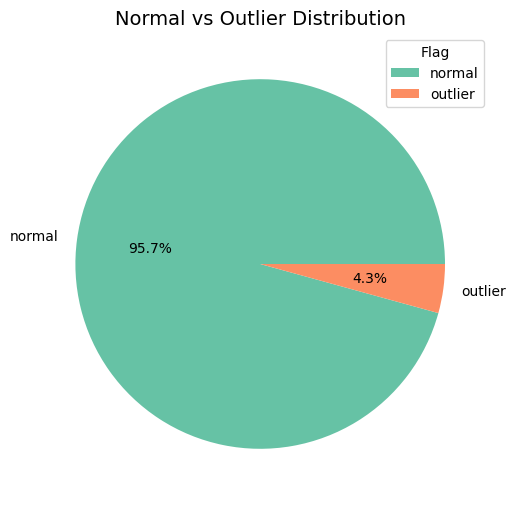

In [ ]:
label_count = inj_pd['defect_flag'].value_counts().reset_index()
label_count.columns = ['defect_flag','count']

plt.figure(figsize=(6,6))
plt.pie(
    label_count['count'],
    labels=label_count['defect_flag'],
    autopct='%1.1f%%',
    colors=plt.cm.Set2.colors,
)
plt.legend(title='Flag')



plt.title('Normal vs Outlier Distribution', fontsize=14)
plt.show()

The pie chart shows the proportion of normal and defective (outlier) samples in the dataset.


---


* About 95.7% of all production cycles are normal, while only 4.3% are classified as outliers.

* This indicates that the dataset is highly imbalanced, with very few defective cases compared to normal ones.

**Label Distribution by Product**

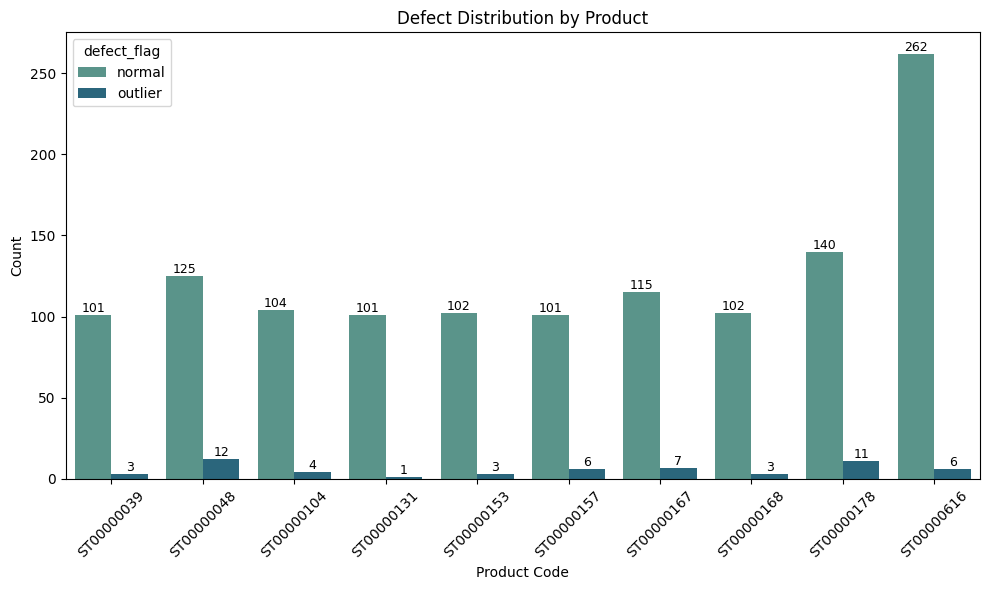

In [ ]:
label_by_product = (
    inj_pd.groupby(['stock_mst_code', 'defect_flag'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=label_by_product,
    x='stock_mst_code',
    y='count',
    hue='defect_flag',
    palette='crest'
)
plt.title('Defect Distribution by Product')
plt.xlabel('Product Code')
plt.ylabel('Count')
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()

This bar chart shows how many normal and defective (outlier) samples exist for each product type (stock_mst_code).

---



* Most products have a small number of outliers compared to normal samples.

* ST0000048 and ST0000178 show relatively higher numbers of outliers, suggesting that these product lines may experience more process variation or instability.

* ST0000616 has the largest total number of samples, but the defect ratio remains low.

To compare the process differences between normal and defective products,
the mean value of each variable was calculated for both groups, and the difference (Normal − Outlier) was visualized to identify variations across process parameters.

The variables were categorized into three groups based on their prefixes:
* CV (Cycle Variables)
* SV (Sensor or Setting Variables)
* Others (additional process or contextual variables).  

This grouping helps to clearly identify which stage of the injection process has the greatest influence on product defects.

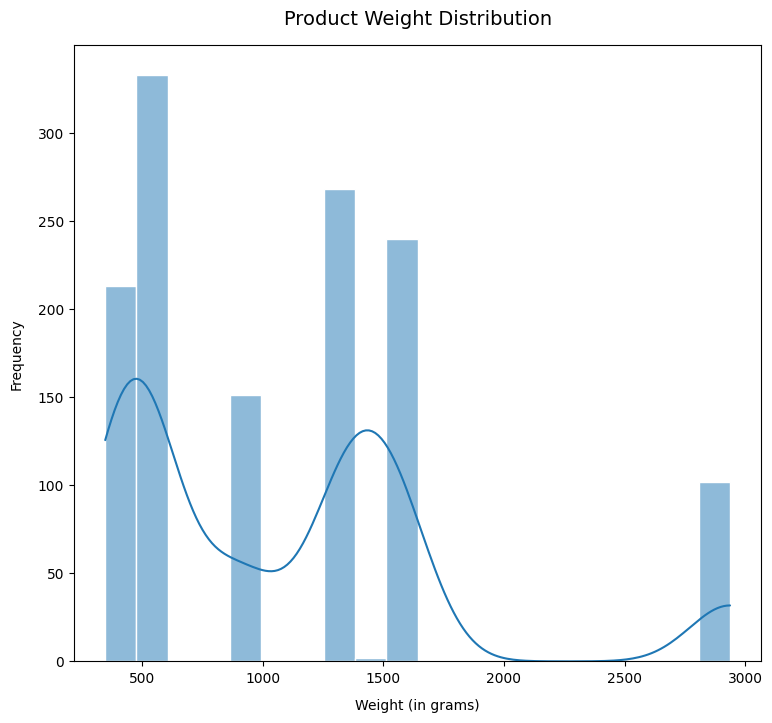

In [ ]:
plt.figure(figsize=(18,8))

#Generate the Historgram
plt.subplot(1,2,1)
sns.set_theme(style="whitegrid", palette="crest")
sns.histplot(inj_pd['weight'], kde =True, bins=20)
plt.title('Product Weight Distribution',fontsize=14, pad=15)
plt.xlabel('Weight (in grams)',labelpad=10)
plt.ylabel('Frequency', labelpad=10)
plt.subplots_adjust(left=0.12, right=0.96)
plt.margins(x=0.05)

The Visualization above shows a multi-modal distribution, meaning the dataset has multiple peaks of central cluster. This indicates that there are different product types or mold configurations.
- Around 450-550g
- Around 900g
- Around 1300g - 1500g
- Around 3000g

It is expected when there are multiple product types into one dataset.

Another indication that the spread of the weight values are very large.

There are some high-value points as well (over 3000g)

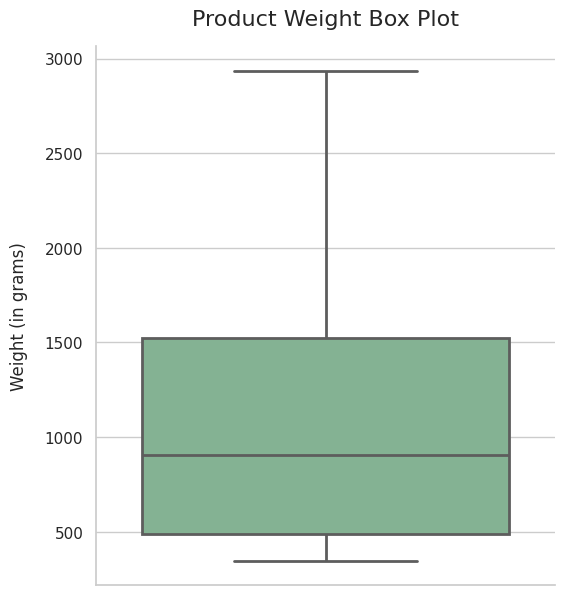

In [ ]:
plt.figure(figsize=(12,7))

#Generate the Historgram
plt.subplot(1,2,1)
sns.set_theme(style="whitegrid", palette="crest")
sns.boxplot(inj_pd['weight'], fliersize =5, linewidth=2)
sns.despine()

plt.title("Product Weight Box Plot", fontsize=16, pad=15)
plt.ylabel("Weight (in grams)", fontsize=12, labelpad=12)
plt.subplots_adjust(left=0.12, right=0.96)
plt.show()


The box plot reveals that the product weight has high variability, from approximately 400g to over 3000g. The interquartile range is qide, indicating substantial differences in production weight across cycle.

In [ ]:
injection_df = inj_pd.copy()
inj_model_df = inj_pd.copy()
inj_model_df['defect_binary'] = inj_model_df['defect_flag'].map({'normal': 0, 'outlier': 1})
injection_df['defect_binary'] = injection_df['defect_flag'].map({'normal': 0, 'outlier': 1})

# Predictor Variables - CV and SV

This section examines both CV and SV features to understand how they relate to defective samples. By exploring correlations and comparing normal versus outlier behavior, we aim to identify which variables may be useful predictors and which ones can be removed due to low impact or redundancy.

To understand which variables would help us predict the product weight, we will have to check which variables correlate the target variables the most. With the use of the correlation map, we would variable correlations and select only those greater than 0.8 correlation.

## CV Categories - Impact analysis

This analysis compares the average values of cycle variables (CV_*) between normal and defective (outlier) samples for each product.

For every product (stock_mst_code), the difference between the mean values of outliers and normal samples was calculated as: Difference = Outlier Mean − Normal Mean

In [ ]:
cv_cols = [c for c in inj_pd.columns if c.startswith('CV_')]

product_order = [
    'ST00000131','ST00000616','ST00000153','ST00000167','ST00000039',
    'ST00000178','ST00000168','ST00000157','ST00000048','ST00000104'
]

rows = []
for code, g in inj_pd.groupby('stock_mst_code'):
    for cv in cv_cols:
        normal = g.loc[g['defect_flag']=='normal', cv].dropna()
        outlier = g.loc[g['defect_flag']=='outlier', cv].dropna()

        n_n = int(normal.shape[0])
        n_o = int(outlier.shape[0])

        mean_n = float(normal.mean()) if n_n else np.nan
        mean_o = float(outlier.mean()) if n_o else np.nan
        diff   = (mean_o - mean_n) if (n_n and n_o) else np.nan

        rows.append({
            'stock_mst_code': code,
            'CV_variable': cv,
            'n_normal': n_n,
            'n_outlier': n_o,
            'normal_mean': mean_n,
            'outlier_mean': mean_o,
            'diff': diff
        })

df_CV = pd.DataFrame(rows)
df_CV['diff'] = df_CV['diff'].round(3)

df_CV


,stock_mst_code,CV_variable,n_normal,n_outlier,normal_mean,outlier_mean,diff
0,ST00000039,CV_001,101,3,56.268846,53.500000,-2.769
1,ST00000039,CV_002,101,3,268.697330,269.000000,0.303
2,ST00000039,CV_003,101,3,11.100000,11.100000,0.000
3,ST00000039,CV_004,101,3,0.000000,0.000000,0.000
4,ST00000039,CV_005,101,3,0.800000,0.833333,0.033
...,...,...,...,...,...,...,...
145,ST00000616,CV_016,262,6,169.587786,167.833333,-1.754
146,ST00000616,CV_017,262,6,624.820611,629.000000,4.179
147,ST00000616,CV_018,262,6,624.820611,629.000000,4.179
148,ST00000616,CV_019,262,6,624.820611,629.000000,4.179


* Most CV variables show only small differences between the two groups (diff values close to 0), meaning that the process is generally stable.

* Some variables, however, have noticeable mean shifts — both positive and negative — which indicate potential links between those parameters and product defects.

* These deviations vary across product types, suggesting that the cause of defects may depend on the specific mold or product design.

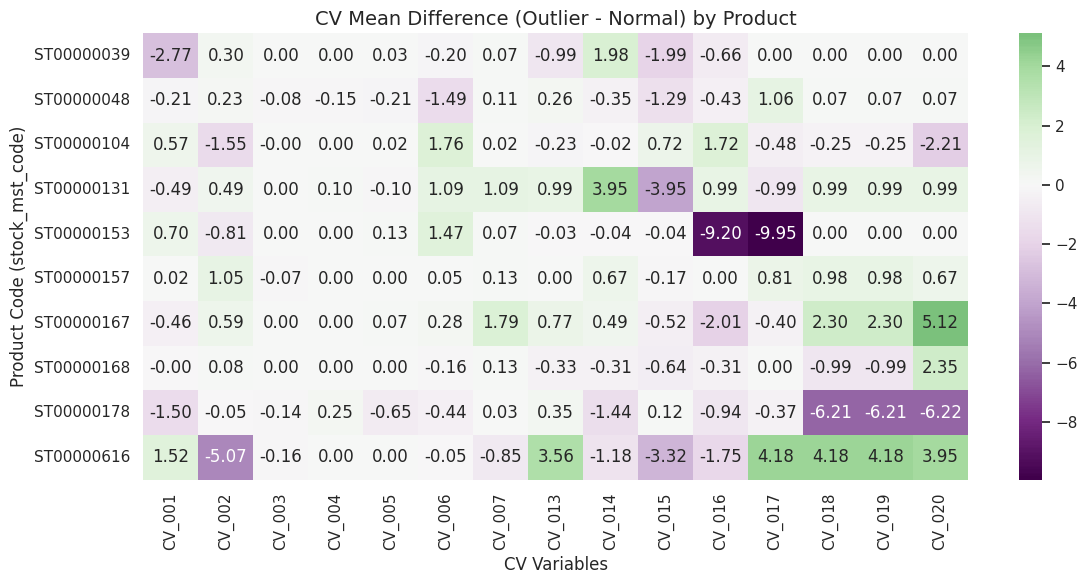

In [ ]:
pivot_diff = df_CV.pivot_table(
    index='stock_mst_code',
    columns='CV_variable',
    values='diff'
)
plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_diff,
    cmap='PRGn',
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("CV Mean Difference (Outlier - Normal) by Product", fontsize=14)
plt.xlabel("CV Variables")
plt.ylabel("Product Code (stock_mst_code)")
plt.tight_layout()
plt.show()

The heatmap visualizes the difference in average CV (Cycle Variable) values between defective (outlier) and normal products for each product type (stock_mst_code).

Color meaning:

* Purple cells — higher CV values in defective products.
* Green cells — lower CV values in defective products.

---



Certain variables (e.g., CV_013, CV_017, CV_018, CV_020) show clear deviations for specific product codes — these may be critical indicators of process imbalance or improper settings.

The pattern of differences varies across products, implying that defects are product-specific rather than caused by a single universal parameter.

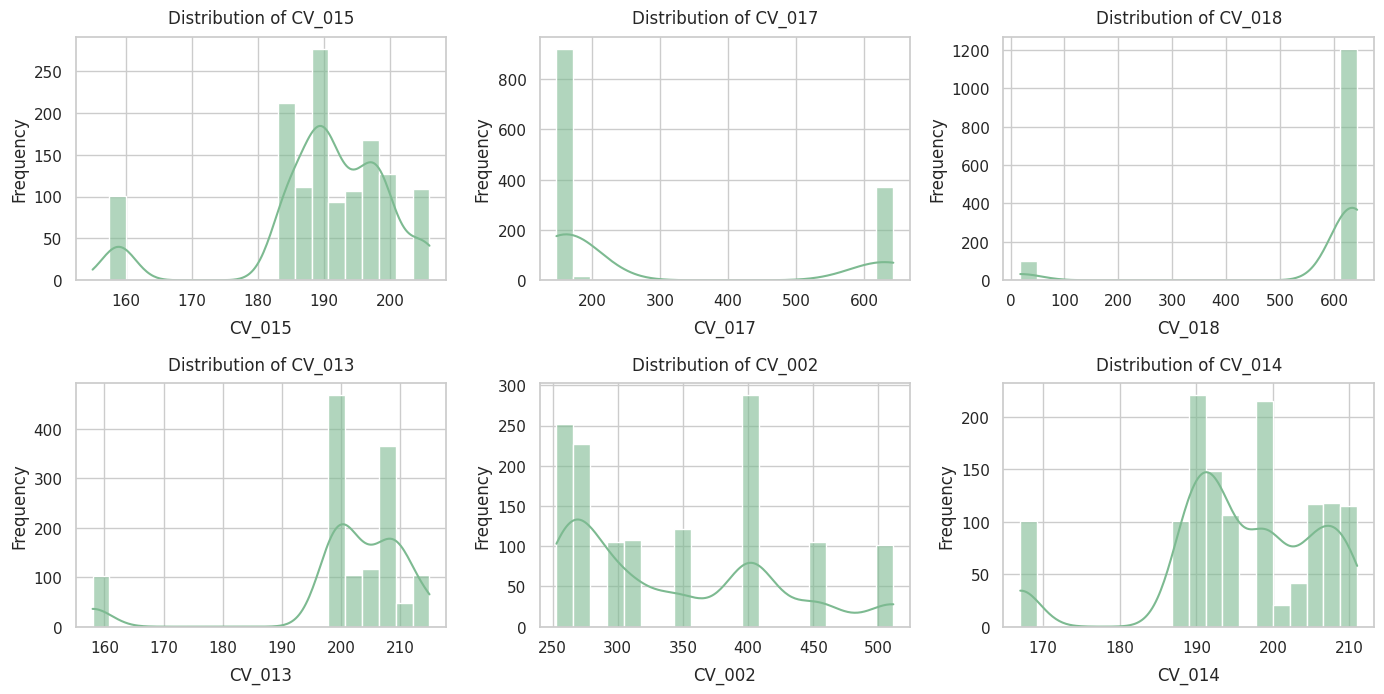

In [ ]:
key_predictors = ['CV_015', 'CV_017', 'CV_018', 'CV_013', 'CV_002', 'CV_014']

plt.figure(figsize=(14,10))

for i, col in enumerate(key_predictors, 1):
    plt.subplot(3, 3, i)
    sns.histplot(inj_model_df[col], kde=True, bins=20, alpha=0.6)
    plt.title(f"Distribution of {col}", fontsize=12, pad=10)
    plt.xlabel(col, labelpad=8)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


**Summary: Impact analysis of CV categories for defect classification**

The comparison between normal and defective samples across CV (Cycle Variable) parameters shows that:

* Most cycle parameters remain stable between normal and defective products,
confirming that the injection process is generally well-controlled.

* However, several CV features (e.g., CV_013, CV_017–CV_020) display noticeable deviations for specific products.

* These shifts indicate that certain process stages—such as injection speed or pressure adjustments—may contribute to the occurrence of defects.

* The variation patterns differ by product type, suggesting that defect causes are product-specific rather than universal.

**Conclusion**

Monitoring and controlling a few key CV parameters can help detect early signs of abnormal production.
These findings provide a foundation for predictive maintenance and future model development.

## SV Categories - Impact analysis


In [ ]:
cv_cols = [c for c in inj_pd.columns if c.startswith('SV')]

product_order = [
    'ST00000131','ST00000616','ST00000153','ST00000167','ST00000039',
    'ST00000178','ST00000168','ST00000157','ST00000048','ST00000104'
]

rows = []
for code, g in inj_pd.groupby('stock_mst_code'):
    for cv in cv_cols:
        normal = g.loc[g['defect_flag']=='normal', cv].dropna()
        outlier = g.loc[g['defect_flag']=='outlier', cv].dropna()

        n_n = int(normal.shape[0])
        n_o = int(outlier.shape[0])

        mean_n = float(normal.mean()) if n_n else np.nan
        mean_o = float(outlier.mean()) if n_o else np.nan
        diff   = (mean_o - mean_n) if (n_n and n_o) else np.nan

        rows.append({
            'stock_mst_code': code,
            'SV_variable': cv,
            'n_normal': n_n,
            'n_outlier': n_o,
            'normal_mean': mean_n,
            'outlier_mean': mean_o,
            'diff': diff
        })

df_SV = pd.DataFrame(rows)
df_SV['diff'] = df_SV['diff'].round(3)

df_SV

,stock_mst_code,SV_variable,n_normal,n_outlier,normal_mean,outlier_mean,diff
0,ST00000039,SV_001,101,3,200.000000,200.0,0.000
1,ST00000039,SV_002,101,3,190.000000,190.0,0.000
2,ST00000039,SV_003,101,3,170.000000,170.0,0.000
3,ST00000039,SV_004,101,3,160.000000,160.0,0.000
4,ST00000039,SV_005,101,3,0.000000,0.0,0.000
...,...,...,...,...,...,...,...
475,ST00000616,SV_057,262,6,0.000000,0.0,0.000
476,ST00000616,SV_058,262,6,0.000000,0.0,0.000
477,ST00000616,SV_059,262,6,0.000000,0.0,0.000
478,ST00000616,SV_060,262,6,50.000000,50.0,0.000


* Most SV variables show no difference between normal and defective groups (diff ≈ 0), which means that machine settings generally remain stable during production.

* A few SV variables (e.g., SV_060, SV_063) display small but noticeable deviations, suggesting that minor setting changes or sensor fluctuations may be linked to defects.

* The differences vary across products, indicating that defect sensitivity to sensor or setting variables depends on the product type.

---



To make the analysis clearer, the SV variables were divided into two groups:

SV Group 1: SV_001 – SV_025

SV Group 2: SV_026 – SV_063

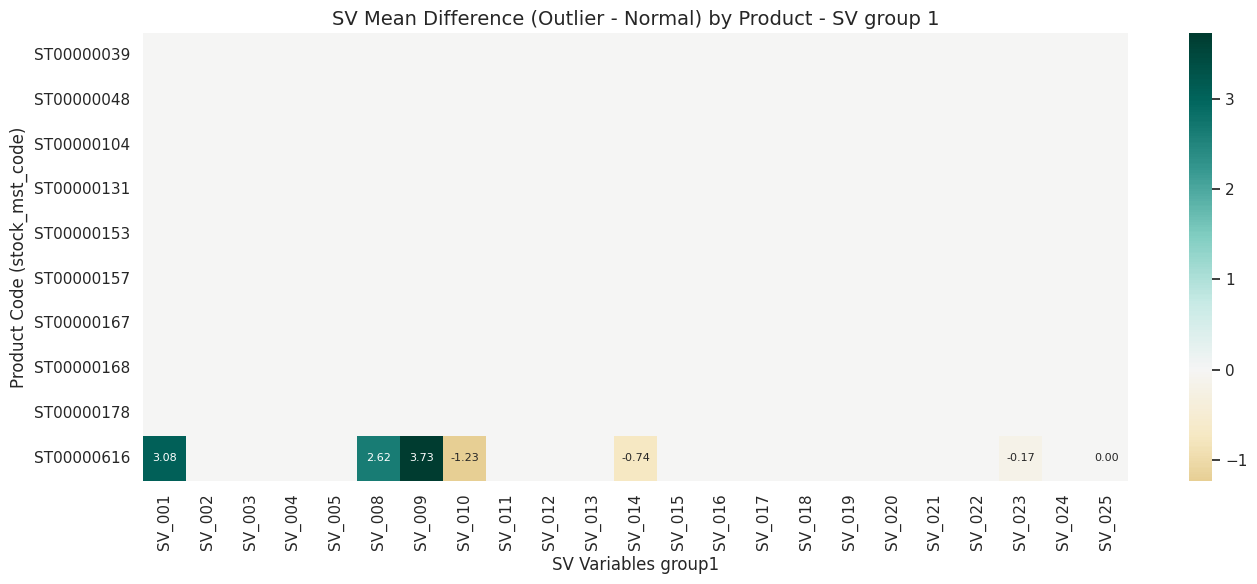

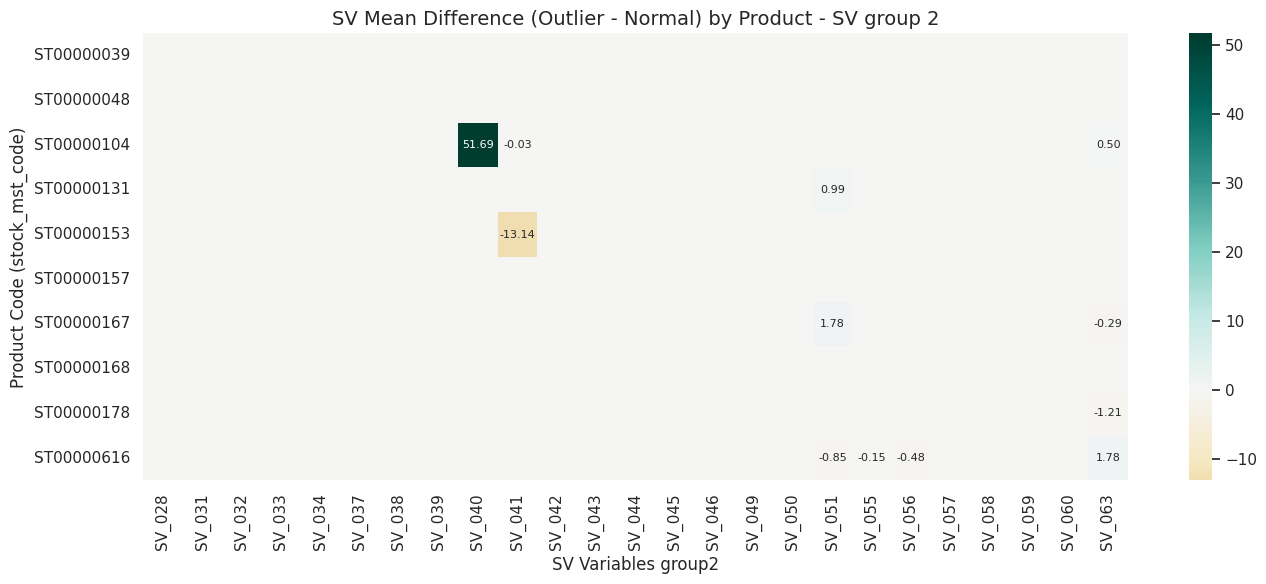

In [ ]:
sv_group1 = [f"SV_{i:03d}" for i in range(1, 26)]   # SV_001 ~ SV_025
sv_group2 = [f"SV_{i:03d}" for i in range(26, 64)]  # SV_026 ~ SV_063

sv_groups = [sv_group1, sv_group2]

for i, subset in enumerate(sv_groups, 1):
    pivot_diff = df_SV[df_SV['SV_variable'].isin(subset)].pivot_table(
        index='stock_mst_code',
        columns='SV_variable',
        values='diff'
    )

    annot_matrix = pivot_diff.copy()
    annot_matrix = pivot_diff.apply(lambda col: col.map(
      lambda v: "" if abs(v) < 1e-6 else f"{v:.2f}"
    ))

    plt.figure(figsize=(14, 6))
    sns.heatmap(
        pivot_diff,
        cmap='BrBG',
        center=0,
        annot=annot_matrix,
        fmt="",
        cbar=True,
        annot_kws={'size': 8}
    )
    plt.title(f"SV Mean Difference (Outlier - Normal) by Product - SV group {i}", fontsize=14)
    plt.xlabel(f"SV Variables group{i}")
    plt.ylabel("Product Code (stock_mst_code)")
    plt.tight_layout()
    plt.show()

The two heatmaps above show the difference in average SV (Setting or Sensor Variable) values between defective (outlier) and normal samples, divided into:

SV Group 1: SV_001 – SV_025

SV Group 2: SV_026 – SV_063

Color meaning:

* Green – higher values for outliers compared to normal samples

* Yellow Brown – lower values for outliers

* Gray – little to no difference

---
**Observations**
* Almost all SV variables show no significant change between normal and defective products (most cells are near 0).

* Only a few variables — notably SV_009, SV_010, and SV_037 for specific products such as ST0000616 and ST0000104 — display visible deviations, suggesting localized sensor or setting shifts during defective cycles.

* These isolated differences imply that machine settings remained stable overall, and defects are more likely related to process execution (CV variables) rather than configuration changes.


**Summary: Impact analysis of SV categories for defect classification**

The comparison between normal and defective samples across SV (Setting / Sensor Variable) parameters shows that:

* Most SV variables remain almost unchanged between normal and defective products (differences close to zero).

* Only a few variables (e.g., SV_009, SV_010, SV_037) show minor deviations for specific products such as ST0000616 and ST0000104.

* This indicates that machine settings and sensors are stable during production, and defects are not primarily caused by setting adjustments.

**Conclusion**

SV variables have limited influence on defect occurrence.
The production issues are likely driven by process dynamics (CV variables) rather than sensor configuration, though a few SVs might still serve as indicators of sensor drift or equipment calibration issues

## Summary of Impact Analysis

Although this impact analysis provides useful exploratory insight, it was not used for the final feature-selection process for several reasons:
* Inconsistency Across Products:
* Not a predictive Metric: MEan differences do not measure the relationship with the target variable.
* Risk of Product-Specific Bias: Variables that appear impactful for one product may not be relevant for others.
* Better Alternatives available: Correlation Analysis and clustering provides clearer insights to reduce dimenionality.

#Data Quality and Preparation

This section evaluates the overall quality of the dataset, including checks for outliers, missing values, and data inconsistencies. It also covers the preparation steps needed to make the data ready for modeling, such as cleaning, transformation, and encoding.

## Missing Data

There were no explicit missing values(nan) in the dataset.  
Therefore, considering the characteristics of the process dataset domain, the first step was to identify variables whose values could be interpreted as MNAR (Missing Not At Random).

In [ ]:
print("total missing(nan) count:", inj_model_df.isna().sum().sum())

total missing(nan) count: 0


Since no explicit missing values were found, both MCAR and MAR were considered as not applicable. But some features may be interpreted as MNAR and being the results of inactive sensors or process configurations

## Selecting Features

With the dataset having a lot of available features, there is a need to minimize the number of features to identify which model will be most effective in this problem set. To refuce dimensionality, we analyze feature correlations with respect to the defect flag. CV and SV variables are separated so that each group can be evaluated independently, allowing us to identify high-impact variables and remove features with weak or redundant correlations.

**CV Variables Correlation Map**




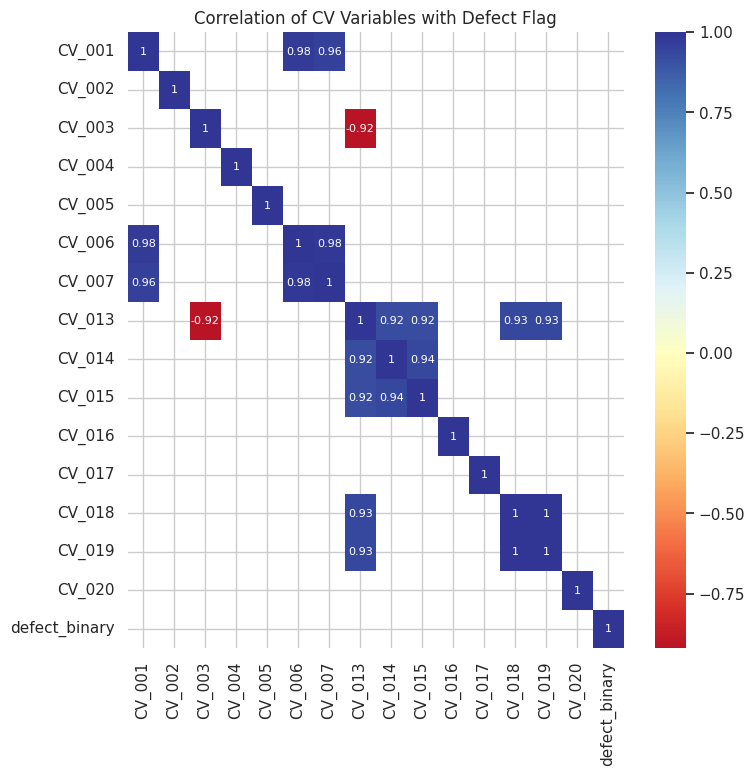

In [ ]:
cv_cols = [col for col in inj_model_df.columns if col.startswith("CV_")]

cv_corr = inj_model_df[cv_cols + ['defect_binary']].corr()
treshold = 0.9
imp_mask = np.abs(cv_corr) > treshold



plt.figure(figsize=(8, 8))
sns.heatmap(cv_corr[imp_mask],
            annot=True,
            cmap="RdYlBu",
            annot_kws={'size': 8},
            center=0)
plt.title("Correlation of CV Variables with Defect Flag")
plt.show()

**Clusters Identified from the CV Correlation Heatmap**

From the heatmap, we can observe several clusters of highly correlated CV features:
* Cluster 1: CV_001, CV_006, CV_007
* Cluster 2: CV_013, CV_014, CV_015
* Cluster 3: CV_018, CV_019
* Cluster 4: CV_017, CV_018

**Selected Features per Cluster**

To minimize redundancy, we select one representative feature from each cluster:
* CV_006
* CV_015
* CV_018 (Cluster 3 and 4 can be combined into one)

**Final Selected CV Features**

Combining the selected cluster representatives with other relevant individual CV features, the final CV feature set becomes:

* CV_003
* CV_004
* CV_005
* CV_006
* CV_015
* CV_016
* CV_018
* CV_020


**SV Variable Correlation Map**

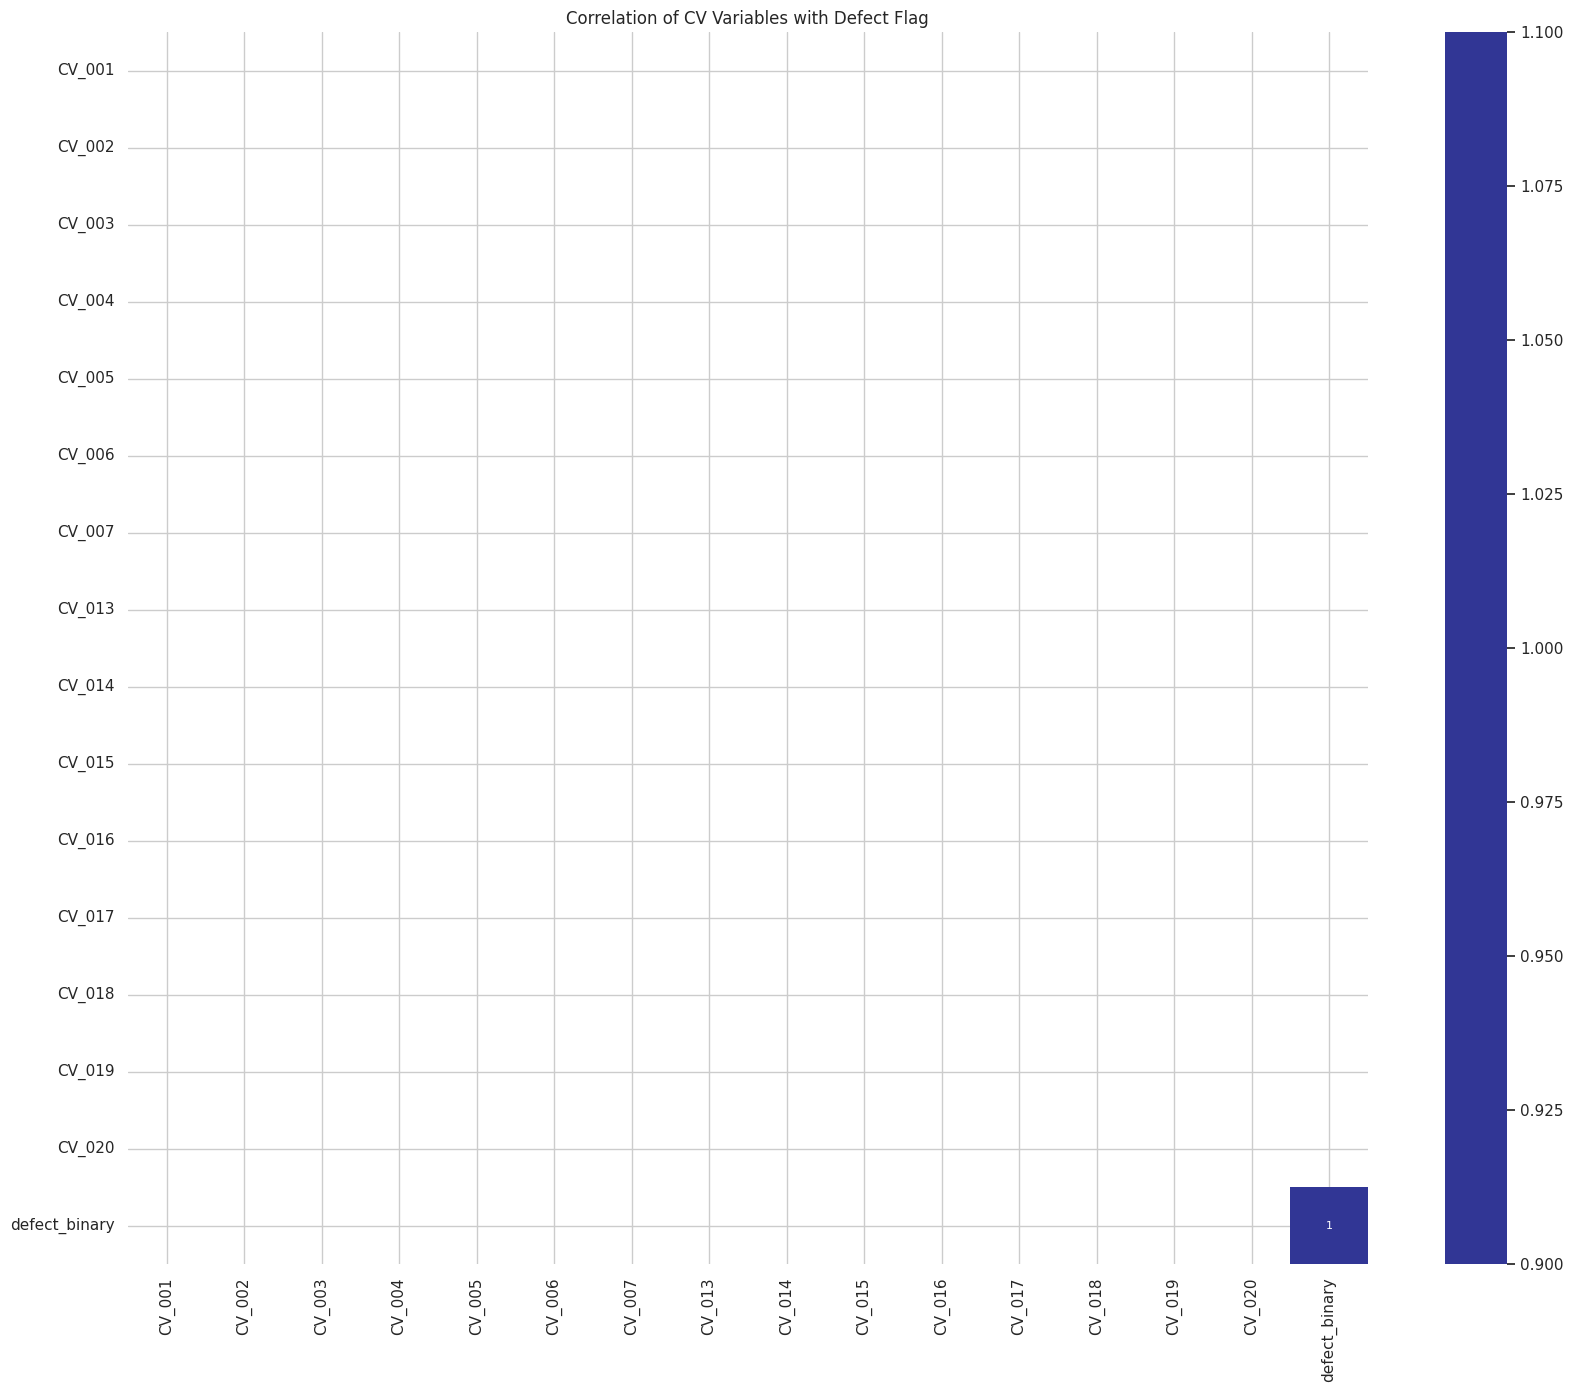

In [ ]:
sv_cols = [col for col in inj_model_df.columns if col.startswith("SV_")]

sv_corr = inj_model_df[sv_cols + ['defect_binary']].corr()
treshold = 0.9
imp_mask = np.abs(sv_corr) > treshold



plt.figure(figsize=(20, 16))
sns.heatmap(cv_corr[imp_mask],
            annot=True,
            cmap="RdYlBu",
            annot_kws={'size': 8},
            center=0)
plt.title("Correlation of CV Variables with Defect Flag")
plt.show()

**Identified SV Clusters from the Correlation Heatmap**

Similar to the CV variables, we observe several groups of highly correlated variables using the SV correlation heatmap. These clusters indicate redundancy, meaning only one representative feature is needed from each group:

*   Cluster 1: SV_001, SV_002, SV_003, SV_004, SV_005
*   Cluster 2: SV_018, SV_019, SV_020
*   Cluster 3: SV_031, SV_032, SV_033, SV_034
*   Cluster 4: SV_037, SV_038, SV_039, SV_040, SV_041
*   Cluster 5: SV_042, SV_043, SV_044, SV_045, SV_046
*   Cluster 6: SV_049, SV_050, SV_051
*   Cluster 7: SV_055, SV_056
*   Cluster 8: SV_057, SV_058
*   Cluster 9: SV_059, SV_060

**Selected Representative Features per Cluster**

To reduce redundancy and minimize the number of features, we selected one representative variable from each cluster:

* SV_003
* SV_018
* SV_031
* SV_037   
* SV_042    
* SV_049
* SV_055    
* SV_057
* SV_059    

**Final Selected SV Feature Set**

Combining these representatives with essential signals identified during EDA, the final SV feature set includes:

* SV_003 - Cylinder temp representative
* SV_013 - Injection pressure/time unique signal
* SV_018 - Injection position representative
* SV_023 - Injection time
* SV_031 - Packing pressure representative
* SV_037 - Metering speed representative
* SV_042 - Metering pressure representative
* SV_049 - Metering position representative
* SV_055 - Back pressure representative
* SV_057 - Forcing speed representative
* SV_059 - Forcing pressure representative
* SV_063 - Cooling time



##Defining the Features and Building the Dataset
This section shows how the dataset is being split and which features are being used in training


In [ ]:
numeric_features = [
    'CV_003','CV_004','CV_005','CV_006','CV_015','CV_016','CV_018','CV_020',
    'SV_003','SV_013','SV_018','SV_023','SV_031',
    'SV_037','SV_042','SV_049','SV_055','SV_057','SV_059','SV_063'
]

categorical_features = ['stock_mst_code', 'MOLD_CAVITY']

X = injection_df[numeric_features + categorical_features]
y = injection_df['defect_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**Validating the Distribution of the Dataset**

In [ ]:
print("Dataset after Splitting:")
print("Training Set Distribution:")
print(y_train.value_counts(normalize=False))
print("\nTraining Set Percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\n----------------------------------\n")

print("Test Set Distribution:")
print(y_test.value_counts(normalize=False))
print("\nTest Set Percentage:")
print(y_test.value_counts(normalize=True) * 100)


Dataset after Splitting:
Training Set Distribution:
defect_binary
0    1002
1      45
Name: count, dtype: int64

Training Set Percentage:
defect_binary
0    95.702006
1     4.297994
Name: proportion, dtype: float64

----------------------------------

Test Set Distribution:
defect_binary
0    251
1     11
Name: count, dtype: int64

Test Set Percentage:
defect_binary
0    95.801527
1     4.198473
Name: proportion, dtype: float64


##Balancing the Training Data

As observed  and mentioned in previous EDA sections, the dataset is highly imbalanced, with very few defective samples. To prevent the model from becoming biased toward the majority class, we apply **RandomOverSampler only to the training set**. This balances the defect and normal classes during training while keeping the test set unchanged for fair evaluation.

In [ ]:
ros = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = ros.fit_resample(X_train, y_train)


In [ ]:
print("Dataset After Training")
print("Training Set Distribution:")
print(y_train_bal.value_counts(normalize=False))
print("\nTraining Set Percentage:")
print(y_train_bal.value_counts(normalize=True) * 100)

print("\n----------------------------------\n")

print("Test Set Distribution:")
print(y_test.value_counts(normalize=False))
print("\nTest Set Percentage:")
print(y_test.value_counts(normalize=True) * 100)

Dataset After Training
Training Set Distribution:
defect_binary
0    1002
1    1002
Name: count, dtype: int64

Training Set Percentage:
defect_binary
0    50.0
1    50.0
Name: proportion, dtype: float64

----------------------------------

Test Set Distribution:
defect_binary
0    251
1     11
Name: count, dtype: int64

Test Set Percentage:
defect_binary
0    95.801527
1     4.198473
Name: proportion, dtype: float64


# Data Modeling

This section contains the following preprocessing of features, definition of models, creating pipelines.

## Preprocessing Steps

This section sets up the preprocessing pipelines used for scaling and encoding the dataset. Multiple transformation methods are defined to compare their impact during model training.

**About ColumnTransformer**
We used a ColumnTransformer as it lets us customize preprocessing for each feature type—scaling numeric columns while encoding categorical ones in a single step. This keeps preprocessing organized and ensures modality of the codes.

Following Preprocessing Functions used:
* StandardScaler
* MinMaxScaler
* PowerTransformer
* PolynomialFeatures
* SplineTransformer
* OneHotEncoding

In [ ]:
preprocess_ss = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
preprocess_mm = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocess_pt = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocess_pf = ColumnTransformer(
    transformers=[
        ('num1', MinMaxScaler(), numeric_features),
        ('num2', PolynomialFeatures(degree=3), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
preprocess_st = ColumnTransformer(
    transformers=[
        ('num1', MinMaxScaler(), numeric_features),
        ('num2', SplineTransformer(degree=3, n_knots=5), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocess_oh = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

##Model Definitions

In this section, we define the machine learning models used for classification:
* Logistic Regression – linear classifier, a standard baseline model
* Decision Tree – rule-based model, interpretable but may be prone to overfitting
* Random Forest – ensemble of trees, reduces overfitting and improves stability
* XGBoost – gradient boosting model, strong performance on tabular data
* KNN – instance-based model relying on distance between samples

In [ ]:
model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)

model_rf = RandomForestClassifier(class_weight='balanced', random_state=42)
#model_rf = RandomForestClassifier(n_estimators=400,max_depth=None,min_samples_split=2,min_samples_leaf=1,class_weight={0:1, 1:20},random_state=42,n_jobs=-1)

model_knn = KNeighborsClassifier()

model_dt = DecisionTreeClassifier(random_state=42,class_weight='balanced')

ratio = (y_train == 0).sum() / (y_train == 1).sum()

model_xgb = XGBClassifier(tree_method='hist', eval_metric="logloss",random_state=42, scale_pos_weight=ratio)
#model_xgb = XGBClassifier(tree_method='hist',scale_pos_weight=22,eval_metric='logloss',max_depth=4,learning_rate=0.05,n_estimators=400,subsample=0.8,colsample_bytree=0.8,random_state=42)

In [ ]:
print("DT in pipeline:",  pipes_group3['dt'].named_steps['dt'])
print("RF in pipeline:",  pipes_group3['rf'].named_steps['rf'])
print("XGB in pipeline:", pipes_group3['xgb'].named_steps['xgb'])


DT in pipeline: DecisionTreeClassifier(class_weight='balanced', random_state=42)
RF in pipeline: RandomForestClassifier(class_weight='balanced', random_state=42)
XGB in pipeline: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


## Creating Pipelines

Pipelines allow us to link preprocessing and model training into a single, clean workflow. This ensures consistent transformations and makes it easier track and evaluate models. However, pipes will be grouped by batches, the best models will be selected for that batch and will be compared to other performing models from other batches.

In [ ]:
#Linear Regression Pipeline Group
pipe1 = Pipeline ([
    ('standard', preprocess_ss),
    ('lr-ss', model_lr)
])

pipe2 = Pipeline ([
    ('minmax', preprocess_mm),
    ('lr-mm', model_lr)
])

pipe3 = Pipeline ([
    ('power', preprocess_pt),
    ('lr-pt', model_lr)
])

pipe4 = Pipeline ([
    ('poly', preprocess_pf),
    ('lr-pf', model_lr)
])

pipe5 = Pipeline ([
    ('spline', preprocess_st),
    ('lr-spl', model_lr)
])

#Pipeline Group 2
pipe6 = Pipeline ([
    ('spline', preprocess_st),
    ('knn-spl', model_knn)
])

pipe7 = Pipeline ([
    ('poly', preprocess_pf),
    ('dt-poly', model_dt)
])


#Pipeline Group 3
pipe8 = Pipeline ([
    ('oh', preprocess_oh),
    ('dt', model_dt)
])

pipe9 = Pipeline ([
    ('oh', preprocess_oh),
    ('rf', model_rf)
])

pipe10 = Pipeline([
    ('oh', preprocess_oh),
    ('xgb', model_xgb)
])

**Creating the Pipe Groups**

In [ ]:
pipes_lr = {
    'lr-standard':pipe1,
    'lr-minmax': pipe2,
    'lr-power': pipe3,
    'lr-poly': pipe4,
    'lr-spline': pipe5
}

In [ ]:
pipes_group2 = { 'knn-spl': pipe6,
                 'dt-poly':pipe7
               }

pipes_group3 = { 'dt': pipe8,
                 'rf': pipe9,
                 'xgb': pipe10
               }

# Data Evaluation

This section includes creating a benchmark model (trained with all the features), running the created pipelines, evaluating these models with one another.

In [ ]:
#Creating a dataframe to store the model results
model_results = pd.DataFrame()
model_results

""


**Function to Train and Test Models**

In [ ]:
#function to train and test one model at a time
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # AUC
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    # compute metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=[0,1])

    # print + plot
    print(f"\nModel: {name}")
    print(f"Accuracy: {acc}")
    print(f"F1 Score: {f1}")
    print(f"AUC Score: {auc}")
    print(classification_report(y_test, y_pred, zero_division=0))

    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Normal","Defect"]).plot(cmap='Blues')

    plt.title(f"Confusion Matrix - {name}")
    plt.grid(False)
    plt.show()

    print("\n----------------------------------------\n\n")
    return {
        "model": name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "cm": cm
    }

**Cross Validation Function**

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

def run_repeated_cv(models, X, y, n_splits=5, n_repeats=10, scoring='f1'):
    all_results = {}

    for name in models.keys():
        all_results[name] = []

    for i in range(n_repeats):
        print(f"\nRepetition {i+1}")
        cv = KFold(n_splits=n_splits, shuffle=True, random_state=i)

        for name, model in models.items():
            print(f"  Running CV → {name}")
            scores = cross_val_score(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
            all_results[name].append(scores.mean())

    df_results = pd.DataFrame(all_results)
    df_results.index = [f"Repeat {i+1}" for i in range(n_repeats)]

    return df_results



## Creating Benchmark Model

We wanted to create a baseline model where we can compare the models and see if using specific models with select features would improve the performance in detecting defects.

In [ ]:
#Creating a dataset with all features
all_numeric_features = [
    col for col in injection_df.columns
    if col.startswith('CV_') or col.startswith('SV_')
]

categorical_benchmark_features = ['stock_mst_code', 'MOLD_CAVITY']

X_bench = injection_df[all_numeric_features + categorical_benchmark_features]
y_bench = injection_df['defect_binary']

X_bench_train, X_bench_test, y_bench_train, y_bench_test = train_test_split(
    X_bench, y_bench,
    test_size=0.2,
    random_state=42,
    stratify=y_bench
)

ros = RandomOverSampler(random_state=42)
X_bench_train_bal, y_bench_train_bal = ros.fit_resample(X_bench_train, y_bench_train)

print("Train shape (before):", X_bench_train.shape)
print("Train shape (after oversampling):", X_bench_train_bal.shape)
print("Test shape:", X_bench_test.shape)

Train shape (before): (1047, 65)
Train shape (after oversampling): (2004, 65)
Test shape: (262, 65)



Model: bench_lr
Accuracy: 0.5725190839694656
F1 Score: 0.125
AUC Score: 0.7576964867801521
              precision    recall  f1-score   support

           0       0.98      0.57      0.72       251
           1       0.07      0.73      0.12        11

    accuracy                           0.57       262
   macro avg       0.52      0.65      0.42       262
weighted avg       0.94      0.57      0.69       262



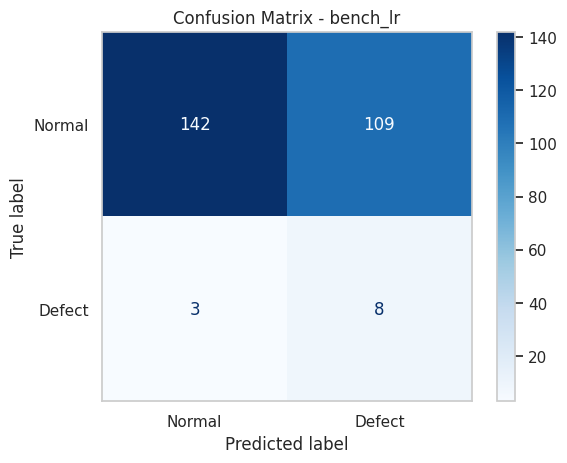


----------------------------------------




In [ ]:
res = evaluate_model("bench_lr", pipe1, X_bench_train,X_bench_test, y_bench_train,y_bench_test)

model_results = pd.concat([model_results, pd.DataFrame([res])],
                          ignore_index=True)

In [ ]:
model_results

,model,accuracy,precision,recall,f1,auc,cm
0,bench_lr,0.572519,0.068376,0.727273,0.125,0.757696,"[[142, 109], [3, 8]]"


####Insight and Observation:

In terms of Performance, the Accuracy of the model is at 0.57%, while Recall is at 0.73 and 0.07, However the F1 score is at 0.125 indicating it detects most defects but produces a number of false alarms.

## Group Pipeline Evaluations

###Group 1 - LogisticRegression Group


Model: lr-standard
Accuracy: 0.6412213740458015
F1 Score: 0.14545454545454545
AUC Score: 0.7124230351321985
              precision    recall  f1-score   support

           0       0.98      0.64      0.77       251
           1       0.08      0.73      0.15        11

    accuracy                           0.64       262
   macro avg       0.53      0.68      0.46       262
weighted avg       0.94      0.64      0.75       262



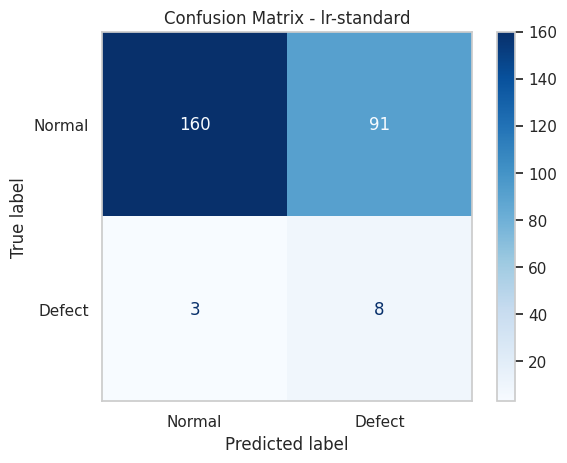


----------------------------------------



Model: lr-minmax
Accuracy: 0.5877862595419847
F1 Score: 0.12903225806451613
AUC Score: 0.7327055414704817
              precision    recall  f1-score   support

           0       0.98      0.58      0.73       251
           1       0.07      0.73      0.13        11

    accuracy                           0.59       262
   macro avg       0.53      0.65      0.43       262
weighted avg       0.94      0.59      0.70       262



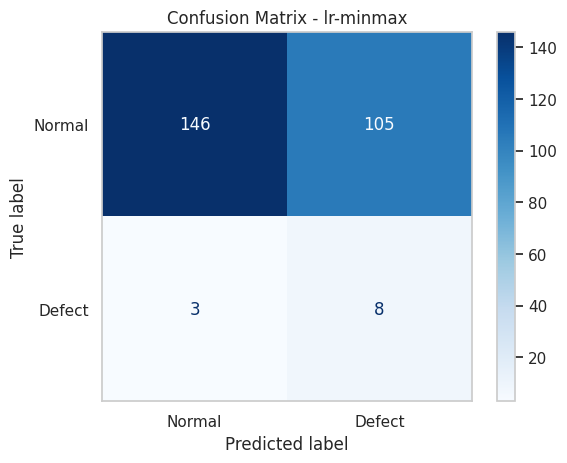


----------------------------------------



Model: lr-power
Accuracy: 0.6374045801526718
F1 Score: 0.12844036697247707
AUC Score: 0.6982977182180369
              precision    recall  f1-score   support

           0       0.98      0.64      0.77       251
           1       0.07      0.64      0.13        11

    accuracy                           0.64       262
   macro avg       0.52      0.64      0.45       262
weighted avg       0.94      0.64      0.74       262



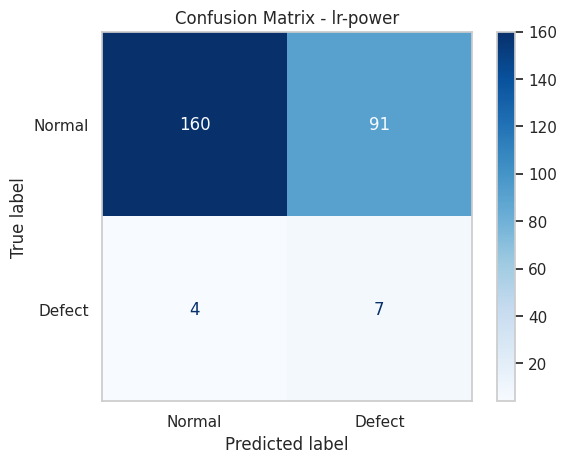


----------------------------------------




/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: lr-poly
Accuracy: 0.9312977099236641
F1 Score: 0.47058823529411764
AUC Score: 0.8145599420499819
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       251
           1       0.35      0.73      0.47        11

    accuracy                           0.93       262
   macro avg       0.67      0.83      0.72       262
weighted avg       0.96      0.93      0.94       262



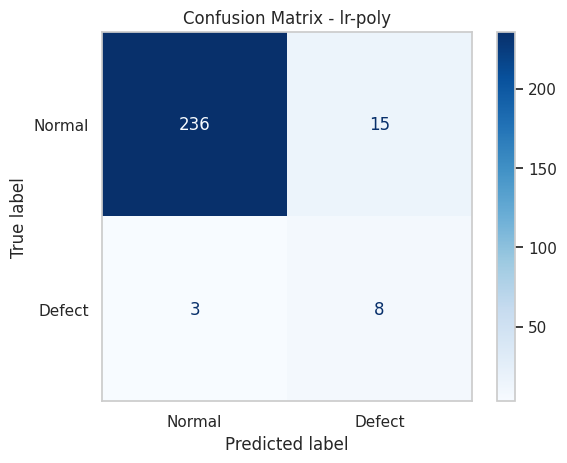


----------------------------------------



Model: lr-spline
Accuracy: 0.8396946564885496
F1 Score: 0.3
AUC Score: 0.8022455632017386
              precision    recall  f1-score   support

           0       0.99      0.84      0.91       251
           1       0.18      0.82      0.30        11

    accuracy                           0.84       262
   macro avg       0.59      0.83      0.60       262
weighted avg       0.96      0.84      0.88       262



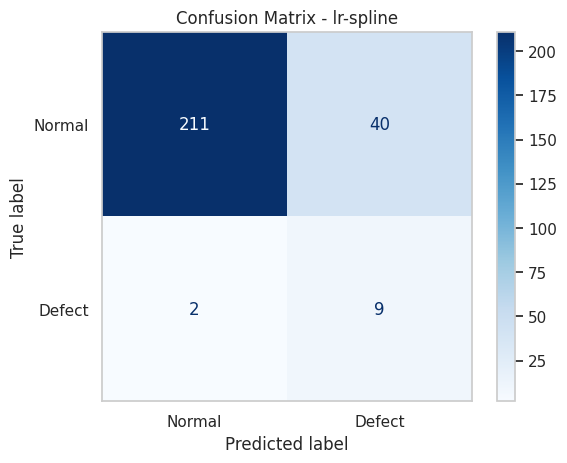


----------------------------------------




In [ ]:
#using X_train_bal, y_train_bal for more balanced

##for pipe_name, pipe in pipes_lr.items():
##    evaluate_model(
##        pipe_name,
##        pipe,
##        X_train_bal,
##        X_test,
##        y_train_bal,
##        y_test
##    )

for name, pipe in pipes_lr.items():
    res = evaluate_model(name, pipe, X_train_bal, X_test, y_train_bal, y_test)
    model_results = pd.concat([model_results, pd.DataFrame([res])],
                              ignore_index=True)

In [ ]:
results_g1 = run_repeated_cv(pipes_lr, X, y, scoring='f1')
pd.DataFrame(results_g1)


Repetition 1
  Running CV → lr-standard
  Running CV → lr-minmax
  Running CV → lr-power
  Running CV → lr-poly
  Running CV → lr-spline

Repetition 2
  Running CV → lr-standard
  Running CV → lr-minmax
  Running CV → lr-power
  Running CV → lr-poly
  Running CV → lr-spline

Repetition 3
  Running CV → lr-standard
  Running CV → lr-minmax
  Running CV → lr-power
  Running CV → lr-poly
  Running CV → lr-spline

Repetition 4
  Running CV → lr-standard
  Running CV → lr-minmax
  Running CV → lr-power
  Running CV → lr-poly
  Running CV → lr-spline

Repetition 5
  Running CV → lr-standard
  Running CV → lr-minmax
  Running CV → lr-power
  Running CV → lr-poly
  Running CV → lr-spline

Repetition 6
  Running CV → lr-standard
  Running CV → lr-minmax
  Running CV → lr-power
  Running CV → lr-poly
  Running CV → lr-spline

Repetition 7
  Running CV → lr-standard
  Running CV → lr-minmax
  Running CV → lr-power
  Running CV → lr-poly
  Running CV → lr-spline

Repetition 8
  Running CV → lr-st

,lr-standard,lr-minmax,lr-power,lr-poly,lr-spline
Repeat 1,0.120774,0.110483,0.123899,0.378479,0.187047
Repeat 2,0.122044,0.134209,0.124931,0.364599,0.157792
Repeat 3,0.131684,0.117818,0.120198,0.322799,0.174519
Repeat 4,0.134779,0.110106,0.140290,0.321873,0.170675
Repeat 5,0.133581,0.113200,0.106701,0.302436,0.158159
Repeat 6,0.102502,0.123574,0.124579,0.307044,0.169052
Repeat 7,0.118944,0.111829,0.131796,0.275108,0.158478
Repeat 8,0.133923,0.115771,0.120176,0.348881,0.159314
Repeat 9,0.113202,0.106113,0.083519,0.299305,0.144539
Repeat 10,0.115901,0.120658,0.115577,0.341075,0.141060


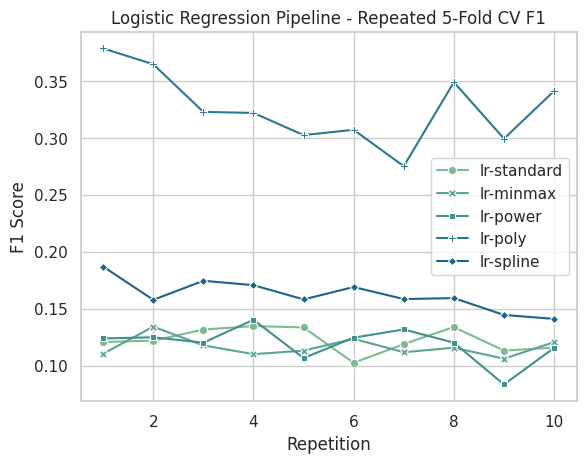

In [ ]:
results_g1.index = range(1, len(results_g1)+1)
#results_g1.index = [f"{i}" for i in range(1, 11)]

sns.lineplot(data=results_g1, markers=True, dashes=False)
plt.title('Logistic Regression Pipeline - Repeated 5-Fold CV F1')
plt.xlabel("Repetition")
plt.ylabel("F1 Score")
plt.show()

####Insights and Observations

For Logistic Regression with Standard, MinMax and Power transformations:
* False Negatives: is around 2-3 meaning it has good recalls
* False Positives: is around 40-90 indicating it has bad precision
* These models tend to predict defects too often thus may lead to false negatives.

For Logistic Regression with Spline:
* False Negatives: is at 2, indicating very good recall
* False Positives: 91, high alarms indicating low recall
* It detects most defects however the false positives are also high.

For Logistic Regression with Polynomial Features:
* False Negatives: is at 2, indicating very good recall
* False Positives: 91, high alarms indicating low recall
* It detects most defects however the false positives are also high.

In terms of performance, Standard and MinMax models performed the weakest among the group, Power Model has lower recall in the group, while Spline performed relatively good. Polynomial Features model has the best balance among this group.

In regards to Cross-Validation Stability, Polynomial Features performed consistently and much higher than all other preprocessors.

Best Model: **Logistic Regression with Polynomial Features**

### Group 2 - Pipeline - pipes_group2


Model: knn-spl
Accuracy: 0.9580152671755725
F1 Score: 0.6206896551724138
AUC Score: 0.8927924664976459
              precision    recall  f1-score   support

           0       0.99      0.96      0.98       251
           1       0.50      0.82      0.62        11

    accuracy                           0.96       262
   macro avg       0.75      0.89      0.80       262
weighted avg       0.97      0.96      0.96       262



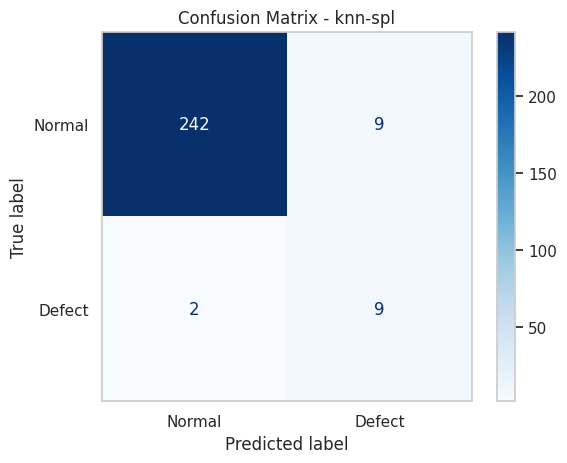


----------------------------------------



Model: dt-poly
Accuracy: 0.9732824427480916
F1 Score: 0.6666666666666666
AUC Score: 0.8122057225642882
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       251
           1       0.70      0.64      0.67        11

    accuracy                           0.97       262
   macro avg       0.84      0.81      0.83       262
weighted avg       0.97      0.97      0.97       262



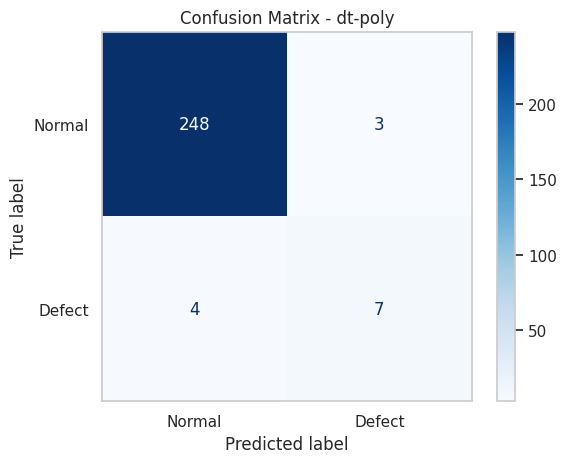


----------------------------------------




In [ ]:
#using X_train_bal, y_train_bal for more balanced

##for pipe_name, pipe in pipes_group2.items():
##    evaluate_model(
##        pipe_name,
##        pipe,
##        X_train_bal,
##        X_test,
##        y_train_bal,
##        y_test
##    )

for name, pipe in pipes_group2.items():
    res = evaluate_model(name, pipe, X_train_bal, X_test, y_train_bal, y_test)
    model_results = pd.concat([model_results, pd.DataFrame([res])],
                              ignore_index=True)

In [ ]:
results_g2 = run_repeated_cv(pipes_group2, X, y, scoring='f1')
pd.DataFrame(results_g2)


Repetition 1
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 2
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 3
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 4
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 5
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 6
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 7
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 8
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 9
  Running CV → knn-spl
  Running CV → dt-poly

Repetition 10
  Running CV → knn-spl
  Running CV → dt-poly


,knn-spl,dt-poly
Repeat 1,0.225505,0.451951
Repeat 2,0.322689,0.482152
Repeat 3,0.245855,0.429074
Repeat 4,0.221825,0.432850
Repeat 5,0.290679,0.468083
Repeat 6,0.230942,0.455874
Repeat 7,0.225556,0.456964
Repeat 8,0.258927,0.490219
Repeat 9,0.098951,0.482251
Repeat 10,0.334249,0.430027


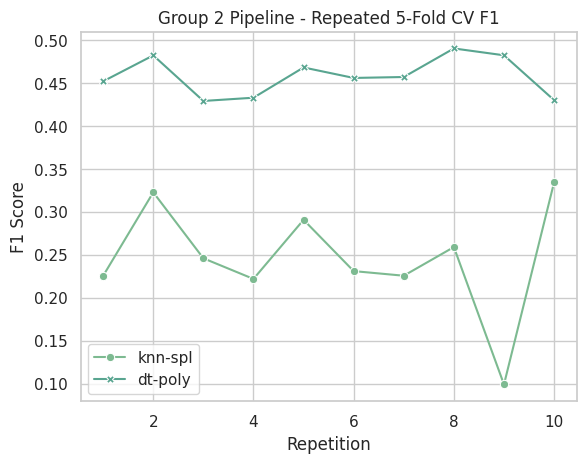

In [ ]:
results_g2.index = range(1, len(results_g1)+1)
#results_g1.index = [f"{i}" for i in range(1, 11)]

sns.lineplot(data=results_g2, markers=True, dashes=False)
plt.title('Group 2 Pipeline - Repeated 5-Fold CV F1')
plt.xlabel("Repetition")
plt.ylabel("F1 Score")
plt.show()

####Insights and Observations

KNN performed great with an F1 score of 0.62, Recall of 0.82, Precision of 0.50 and AUC of 0.893. This has resulted into few false negatives and moderate false positives.

Decision Tree (with Transformation) also performed greate with an F1 score of 0.67, Precision 0f 0.70, Recall = 0.64 and AUC = 0.812. False Negatives is at 4 while False Positives = 3.

To sumarize in terms of Performance, Decision Tree did very good on F1 and precision metrics, while KNN performed better on recall and AUC

Best Models: **Both KNN and Decision Tree (with Transformation)**




### Group 3 - Pipeline - pipes_group3


Model: dt
Accuracy: 0.6183206106870229
F1 Score: 0.13793103448275862
AUC Score: 0.700289750090547
              precision    recall  f1-score   support

           0       0.98      0.61      0.75       251
           1       0.08      0.73      0.14        11

    accuracy                           0.62       262
   macro avg       0.53      0.67      0.45       262
weighted avg       0.94      0.62      0.73       262



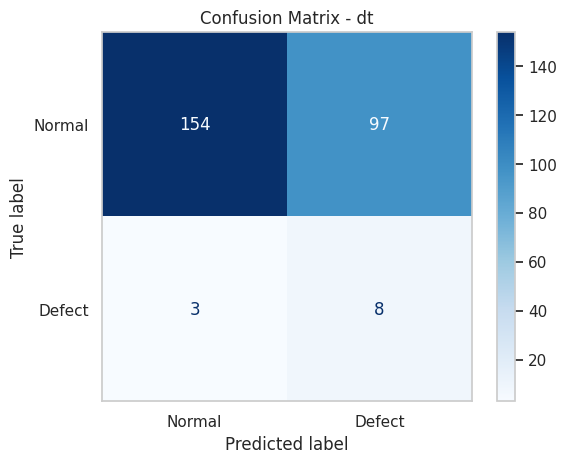


----------------------------------------



Model: rf
Accuracy: 0.6183206106870229
F1 Score: 0.13793103448275862
AUC Score: 0.6926838102136907
              precision    recall  f1-score   support

           0       0.98      0.61      0.75       251
           1       0.08      0.73      0.14        11

    accuracy                           0.62       262
   macro avg       0.53      0.67      0.45       262
weighted avg       0.94      0.62      0.73       262



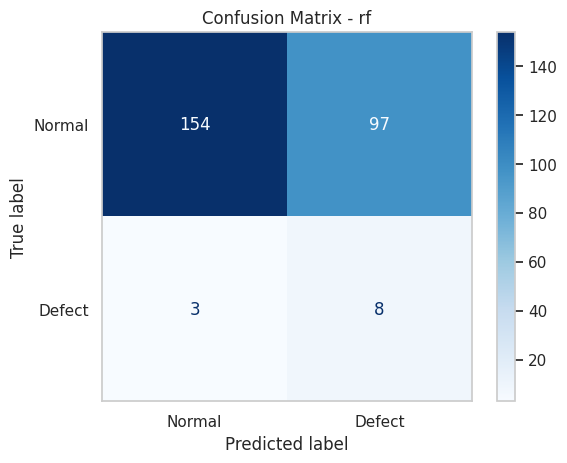


----------------------------------------



Model: xgb
Accuracy: 0.6183206106870229
F1 Score: 0.13793103448275862
AUC Score: 0.700289750090547
              precision    recall  f1-score   support

           0       0.98      0.61      0.75       251
           1       0.08      0.73      0.14        11

    accuracy                           0.62       262
   macro avg       0.53      0.67      0.45       262
weighted avg       0.94      0.62      0.73       262



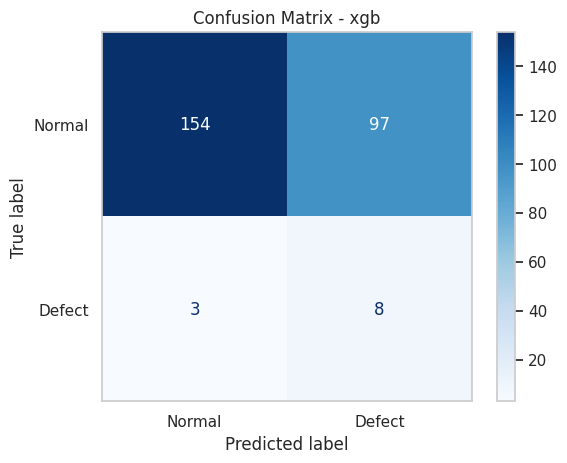


----------------------------------------




In [ ]:
#using X_train_bal, y_train_bal for more balanced

##for pipe_name, pipe in pipes_group3.items():
##    evaluate_model(
##        pipe_name,
##        pipe,
##        X_train_bal,
##        X_test,
##        y_train_bal,
##        y_test
##    )

##Training them on the imbalance dataset so it would not explode

for name, pipe in pipes_group3.items():
    res = evaluate_model(name, pipe, X_train, X_test, y_train, y_test)
    model_results = pd.concat([model_results, pd.DataFrame([res])],
                              ignore_index=True)

In [ ]:
results_g3 = run_repeated_cv(pipes_group3, X, y, scoring='f1')
pd.DataFrame(results_g3)


Repetition 1
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 2
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 3
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 4
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 5
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 6
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 7
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 8
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 9
  Running CV → dt
  Running CV → rf
  Running CV → xgb

Repetition 10
  Running CV → dt
  Running CV → rf
  Running CV → xgb


,dt,rf,xgb
Repeat 1,0.113174,0.115028,0.113174
Repeat 2,0.108494,0.112161,0.108494
Repeat 3,0.101438,0.108104,0.101438
Repeat 4,0.119269,0.111929,0.116692
Repeat 5,0.106314,0.106155,0.100592
Repeat 6,0.116714,0.112278,0.114435
Repeat 7,0.115515,0.115692,0.115515
Repeat 8,0.112762,0.106093,0.110011
Repeat 9,0.095148,0.100502,0.112121
Repeat 10,0.118165,0.123969,0.117904


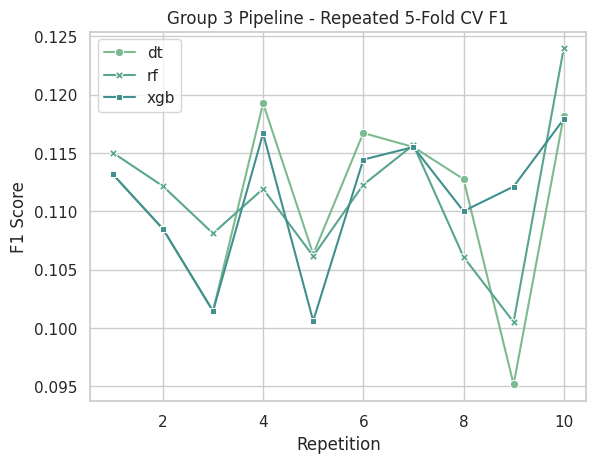

In [ ]:
results_g3.index = range(1, len(results_g3)+1)
#results_g1.index = [f"{i}" for i in range(1, 11)]

sns.lineplot(data=results_g3, markers=True, dashes=False)
plt.title('Group 3 Pipeline - Repeated 5-Fold CV F1')
plt.xlabel("Repetition")
plt.ylabel("F1 Score")
plt.show()

####Insights and Observations
DecisionTree (With OneHotEncoding only) had an F1 score of 0.138, Precision of 0.08, Recall = 0.73.

Random Forest had the exact results as the DecisionTree in this group.

XGBoost had the weakest performance as it resulted with a F1 score of 0.08, Accuracy of 0.04. Also predicted the samples as defect. This is because due to the oversampling + scale_post_weight functions added to this model.

Best Model: Overall group 3 resulted to bad results. However, we would still select a model as the best model in this group.

**RandomForest** is more standard and expected to perform better than a decision tree, as used and established in the industry.

####Testing XGBoost in the all-feature Dataset


Model: xgboost_check
Accuracy: 0.5725190839694656
F1 Score: 0.125
AUC Score: 0.7576964867801521
              precision    recall  f1-score   support

           0       0.98      0.57      0.72       251
           1       0.07      0.73      0.12        11

    accuracy                           0.57       262
   macro avg       0.52      0.65      0.42       262
weighted avg       0.94      0.57      0.69       262



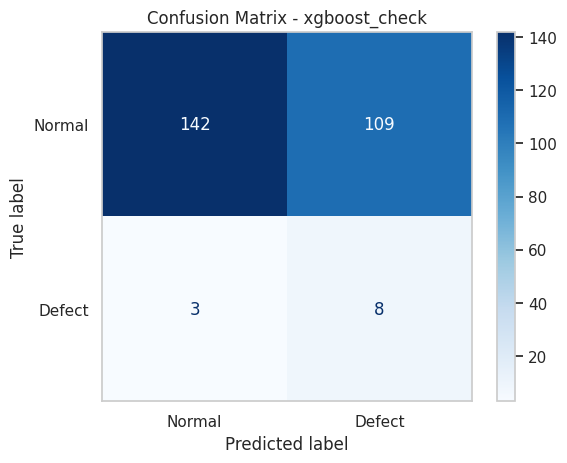


----------------------------------------




In [ ]:
#checking if XGboost would yield different results if trained using the all-feature dataset
#evaluate_model("xgboost_check", pipe10, X_train,X_test, y_train,y_test)

res_xgb = evaluate_model("xgboost_check", pipe1, X_bench_train,X_bench_test, y_bench_train,y_bench_test)

model_results = pd.concat([model_results, pd.DataFrame([res_xgb])],
                          ignore_index=True)

####Investigating Group 3 Results

In [ ]:
print("y_train distribution:\n", y_train.value_counts(normalize=True) * 100)


y_train distribution:
 defect_binary
0    95.702006
1     4.297994
Name: proportion, dtype: float64


In [ ]:
print("y_train_bal distribution:\n", y_train_bal.value_counts(normalize=True) * 100)


y_train_bal distribution:
 defect_binary
0    50.0
1    50.0
Name: proportion, dtype: float64


In [ ]:
print("Using X_train shape:", X_train.shape)
print("Using y_train distribution:\n", y_train.value_counts())

print("\nModel definitions:")
print(model_dt)
print(model_rf)
print(model_xgb)

Using X_train shape: (1047, 22)
Using y_train distribution:
 defect_binary
0    1002
1      45
Name: count, dtype: int64

Model definitions:
DecisionTreeClassifier(class_weight='balanced', random_state=42)
RandomForestClassifier(class_weight='balanced', random_state=42)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_job

In [ ]:
print("DT in pipeline:",  pipes_group3['dt'].named_steps['dt'])
print("RF in pipeline:",  pipes_group3['rf'].named_steps['rf'])
print("XGB in pipeline:", pipes_group3['xgb'].named_steps['xgb'])


DT in pipeline: DecisionTreeClassifier(class_weight='balanced', random_state=42)
RF in pipeline: RandomForestClassifier(class_weight='balanced', random_state=42)
XGB in pipeline: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


**XGBoost on the imbalanced dataset**

The results is the exact same performance profile as its groupmates:
- Random Forest (rf)
- Decision Tree only (dt2)

Indicating:
- High recall (good detection)
- Very low precision (far too many false positives)
- Weak F1 because precision collapses


#Model Selection

This section contains more comparison on the selected models from each group. To summarize below are the selected models from its respective groups:

* Benchmark Model: Logistic Regression with MinMaxScaler (trained on all CV/SV)
* Group 1 Winner: Polynomial Logistic Regression
* Group 2 Winner: Decision Tree, KNN
* Group 3 Winner: Random Forest — but performance is poor

In [ ]:
model_results

,model,accuracy,precision,recall,f1,auc,cm
0,bench_lr,0.572519,0.068376,0.727273,0.125000,0.757696,"[[142, 109], [3, 8]]"
1,lr-standard,0.641221,0.080808,0.727273,0.145455,0.712423,"[[160, 91], [3, 8]]"
2,lr-minmax,0.587786,0.070796,0.727273,0.129032,0.732706,"[[146, 105], [3, 8]]"
3,lr-power,0.637405,0.071429,0.636364,0.128440,0.698298,"[[160, 91], [4, 7]]"
4,lr-poly,0.931298,0.347826,0.727273,0.470588,0.814560,"[[236, 15], [3, 8]]"
5,lr-spline,0.839695,0.183673,0.818182,0.300000,0.802246,"[[211, 40], [2, 9]]"
6,knn-spl,0.958015,0.500000,0.818182,0.620690,0.892792,"[[242, 9], [2, 9]]"
7,dt-poly,0.973282,0.700000,0.636364,0.666667,0.812206,"[[248, 3], [4, 7]]"
8,dt,0.618321,0.076190,0.727273,0.137931,0.700290,"[[154, 97], [3, 8]]"
9,rf,0.618321,0.076190,0.727273,0.137931,0.692684,"[[154, 97], [3, 8]]"


In [ ]:
#Use only if you want to clear group 3 results
model_results = model_results.drop([8, 9, 10, 11])

In [ ]:
final_models = ['bench_lr', 'lr-poly', 'knn-spl', 'dt', 'rf']

df_plot = model_results[model_results['model'].isin(final_models)].reset_index(drop=True)
df_plot

,model,accuracy,precision,recall,f1,auc,cm
0,bench_lr,0.572519,0.068376,0.727273,0.125000,0.757696,"[[142, 109], [3, 8]]"
1,lr-poly,0.931298,0.347826,0.727273,0.470588,0.814560,"[[236, 15], [3, 8]]"
2,knn-spl,0.958015,0.500000,0.818182,0.620690,0.892792,"[[242, 9], [2, 9]]"
3,dt,0.618321,0.076190,0.727273,0.137931,0.700290,"[[154, 97], [3, 8]]"
4,rf,0.618321,0.076190,0.727273,0.137931,0.692684,"[[154, 97], [3, 8]]"


/tmp/ipython-input-2172445592.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='model', y='f1', palette='viridis')


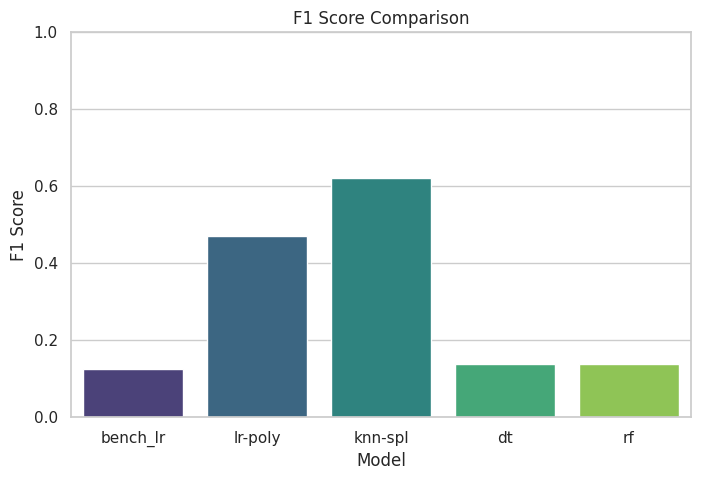

In [ ]:
#bar plot for F1 Score
plt.figure(figsize=(8,5))
sns.barplot(data=df_plot, x='model', y='f1', palette='viridis')

plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.show()


##F1 Score Comparison
* KNN-Spline achieves the highest F1 score, showing it is the most effective at correctly identifying defective samples.
* Polynomial Logistic Regression performs moderately well.
* Benchmark LR, Decision Tree, and Random Forest all show very low F1, meaning they struggle with the minority defect class.

/tmp/ipython-input-2636555175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='model', y='auc', palette='magma')


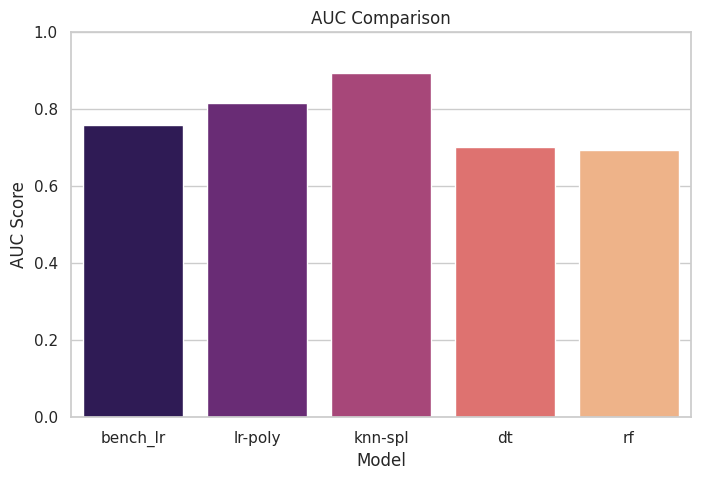

In [ ]:
#AUC Score

plt.figure(figsize=(8,5))
sns.barplot(data=df_plot, x='model', y='auc', palette='magma')

plt.title("AUC Comparison")
plt.ylabel("AUC Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.show()


##AUC Comparison

* All models achieve relatively high AUC, meaning they can separate classes reasonably well.
* KNN-Spline again leads with the highest AUC, confirming strong ranking ability.
* Decision Tree and Random Forest have noticeably lower AUC, reflecting weaker discrimination capability.

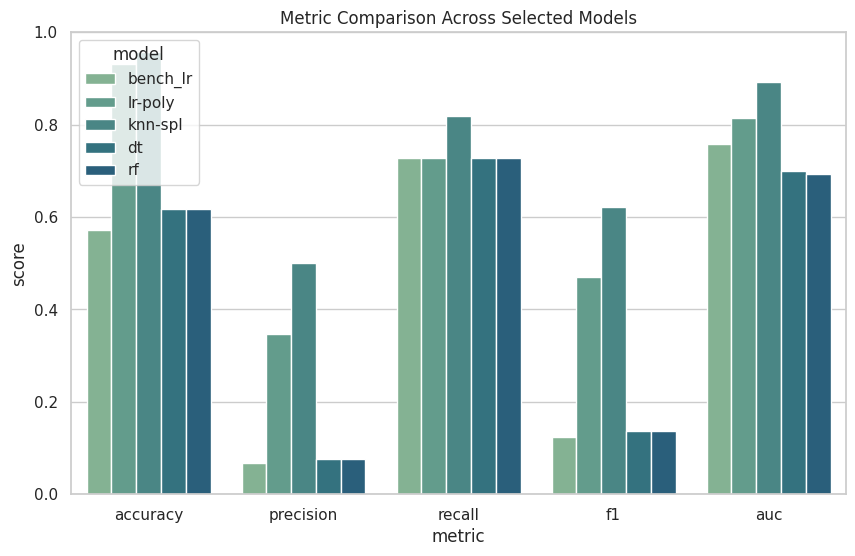

In [ ]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
df_melted = df_plot.melt(id_vars='model', value_vars=metrics, var_name='metric', value_name='score')

plt.figure(figsize=(10,6))
sns.barplot(data=df_melted, x='metric', y='score', hue='model')
plt.title("Metric Comparison Across Selected Models")
plt.ylim(0, 1)
plt.show()


##Metric Comparison

**Accuracy**

* Polynomial LR and KNN-Spline show the highest accuracy, indicating strong overall classification capability.
* Decision Tree and Random Forest have lower accuracy due to frequent misclassifications of the majority class.

**Precision**

* Polynomial LR achieves the highest precision among the models, meaning it produces fewer false positives.
* KNN-Spline has moderate precision but still acceptable.
* DT, RF, and Benchmark LR exhibit extremely low precision, showing a tendency to incorrectly label normal items as defects.

**Recall**
* NN-Spline achieves the highest recall (>0.80), meaning it is best at detecting defects.
* LR-Poly, DT, and RF have similar recall (~0.72), but DT and RF achieve this by overpredicting defects, not by learning better patterns.
* Benchmark LR has poor recall (~0.27), missing most of the defect cases.

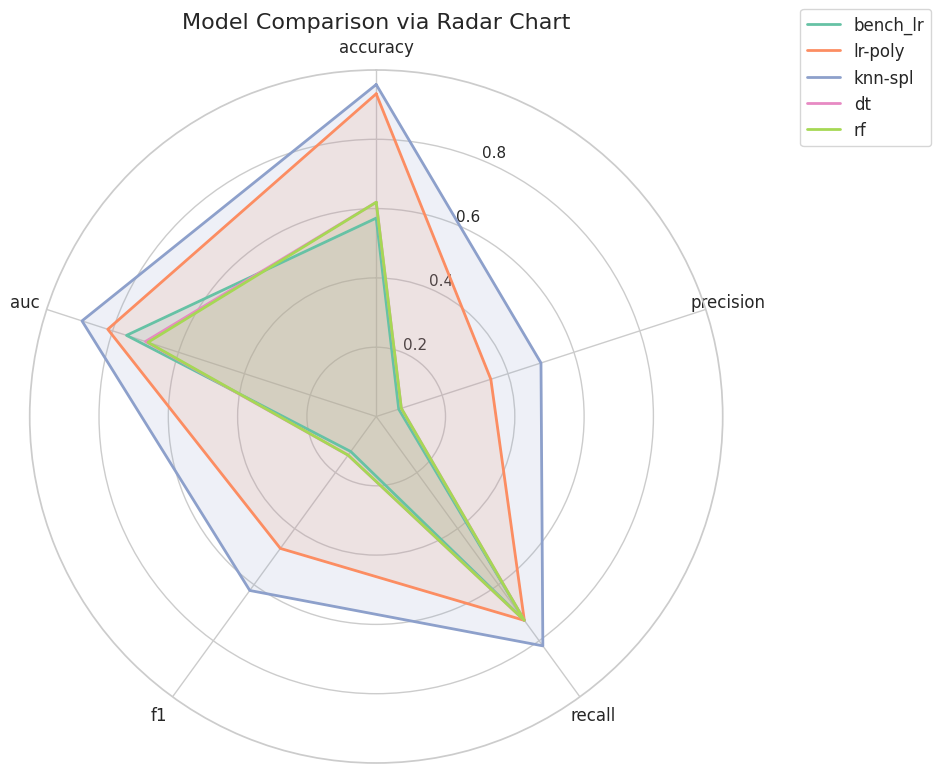

In [ ]:
final_models = ['bench_lr', 'lr-poly', 'knn-spl', 'dt', 'rf']
df_plot = model_results[model_results['model'].isin(final_models)].reset_index(drop=True)

# Distinct colors
palette = sns.color_palette("Set2", n_colors=len(df_plot))

metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
N = len(metrics)

# Base angles
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles.append(angles[0])

plt.figure(figsize=(9, 9))
ax = plt.subplot(111, polar=True)

# Rotate and direction
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

for idx, (_, row) in enumerate(df_plot.iterrows()):
    values = row[metrics].tolist()
    values.append(values[0])

    ax.plot(angles, values,
            linewidth=2,
            linestyle='-',
            label=row['model'],
            color=palette[idx])
    ax.fill(angles, values, alpha=0.15, color=palette[idx])

# axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=12)

ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=11)
ax.set_ylim(0, 1)

plt.legend(loc='upper left', bbox_to_anchor=(1.1, 1.1), fontsize=12)
plt.title("Model Comparison via Radar Chart", fontsize=16, pad=30)
plt.show()

Metric Comparison using the Radal Chart

##Final Insights

Given the results, we recommend using the KNN-spline as the best model for this dataset as its overall performance across metric is remarkable and within standards. It also exceedingly passed the score of the baseline model trained across all CV/SV features proving its effectivity of methodology and across the dataset.

Upon Checking, we note that KNN-Spline is the most effective due to the interaction between the features and transformations. Some possible reasons are:
- SPline Transformation turned nonlinear sensor patterns into smooth features.
- KNN works by grouping similar samples in feature spaces and classifying based on proximity.
- The Oversampling also helped KNN learn from the minority class more effectively.
- Since majority of the data is continous values, KNN can handle these kind of data very well.


#Bonus: Interpretability

We also wanted to check if we can investigate which features influence the model's decision the most. So we have decided to conducted a small, quick and easy SHAP analysis:



  0%|          | 0/262 [00:00<?, ?it/s]

SHAP values shape: (262, 172, 2)
X_explain_df shape: (262, 172)


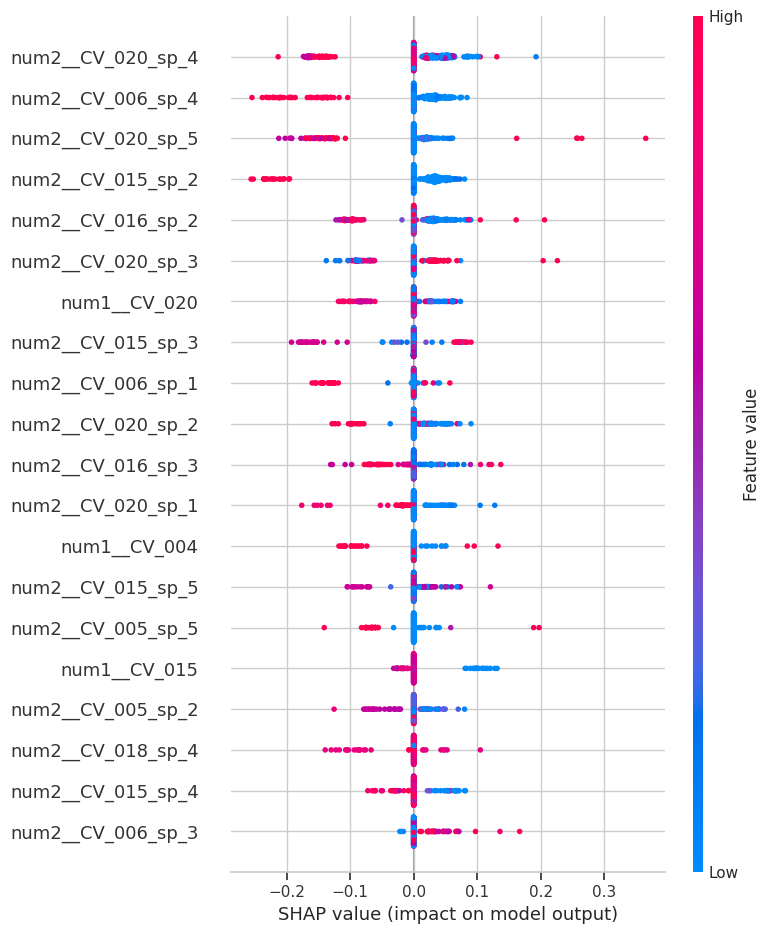

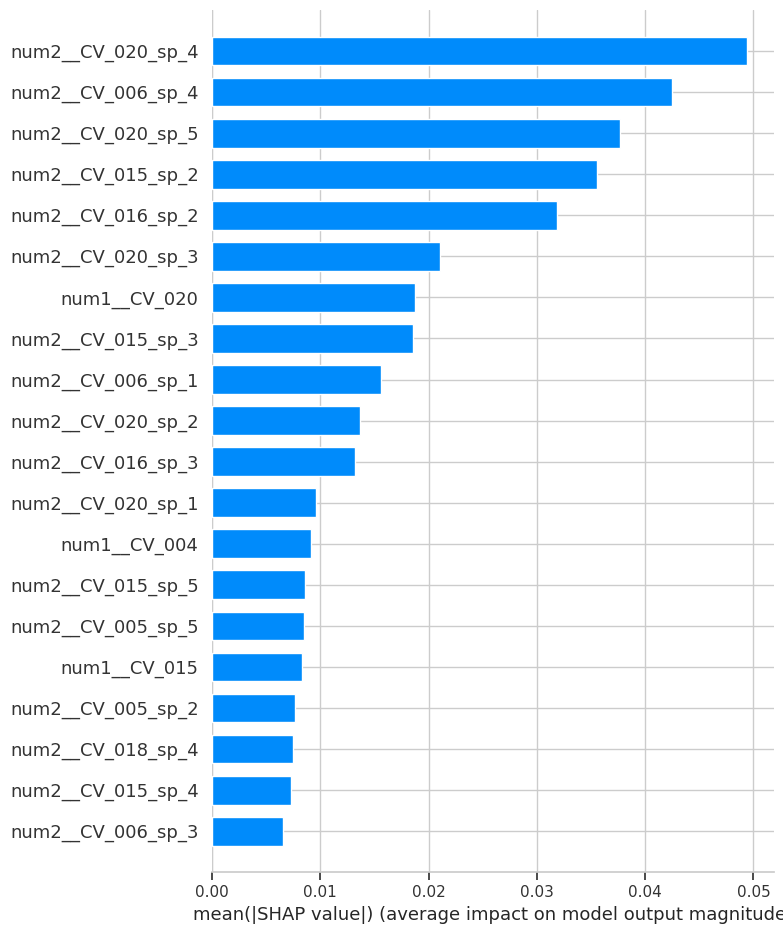

In [ ]:

shap.initjs()

numeric_features = [
    'CV_003','CV_004','CV_005','CV_006','CV_015','CV_016','CV_018','CV_020',
    'SV_003','SV_013','SV_018','SV_023','SV_031',
    'SV_037','SV_042','SV_049','SV_055','SV_057','SV_059','SV_063'
]
categorical_features = ['stock_mst_code', 'MOLD_CAVITY']
final_features = numeric_features + categorical_features

X_explain_raw = X_test[final_features].copy()

#KNN pipeline
pipe = pipe6
preprocessor = pipe.named_steps['spline']
model        = pipe.named_steps['knn-spl']

X_explain = preprocessor.transform(X_explain_raw)
feature_names = preprocessor.get_feature_names_out()
X_explain_df = pd.DataFrame(X_explain, columns=feature_names)


X_bg_raw = X_train[final_features].sample(
    min(100, len(X_train)), random_state=42
)

X_bg = preprocessor.transform(X_bg_raw)
f = lambda x: model.predict_proba(x)
explainer = shap.KernelExplainer(f, X_bg)


shap_values = explainer.shap_values(X_explain_df.values)

print("SHAP values shape:", np.array(shap_values).shape)
print("X_explain_df shape:", X_explain_df.shape)

shap_values_class1 = shap_values[:, :, 1]
shap.summary_plot(
    shap_values_class1,
    X_explain_df
)

shap.summary_plot(
    shap_values_class1,
    X_explain_df,
    plot_type="bar"
)


In [ ]:
print("shap_values[1] shape:", shap_values[1].shape)
print("X_explain_df shape:", X_explain_df.shape)
print("X_explain_df columns:", X_explain_df.columns.tolist())


shap_values[1] shape: (172, 2)
X_explain_df shape: (262, 172)
X_explain_df columns: ['num1__CV_003', 'num1__CV_004', 'num1__CV_005', 'num1__CV_006', 'num1__CV_015', 'num1__CV_016', 'num1__CV_018', 'num1__CV_020', 'num1__SV_003', 'num1__SV_013', 'num1__SV_018', 'num1__SV_023', 'num1__SV_031', 'num1__SV_037', 'num1__SV_042', 'num1__SV_049', 'num1__SV_055', 'num1__SV_057', 'num1__SV_059', 'num1__SV_063', 'num2__CV_003_sp_0', 'num2__CV_003_sp_1', 'num2__CV_003_sp_2', 'num2__CV_003_sp_3', 'num2__CV_003_sp_4', 'num2__CV_003_sp_5', 'num2__CV_003_sp_6', 'num2__CV_004_sp_0', 'num2__CV_004_sp_1', 'num2__CV_004_sp_2', 'num2__CV_004_sp_3', 'num2__CV_004_sp_4', 'num2__CV_004_sp_5', 'num2__CV_004_sp_6', 'num2__CV_005_sp_0', 'num2__CV_005_sp_1', 'num2__CV_005_sp_2', 'num2__CV_005_sp_3', 'num2__CV_005_sp_4', 'num2__CV_005_sp_5', 'num2__CV_005_sp_6', 'num2__CV_006_sp_0', 'num2__CV_006_sp_1', 'num2__CV_006_sp_2', 'num2__CV_006_sp_3', 'num2__CV_006_sp_4', 'num2__CV_006_sp_5', 'num2__CV_006_sp_6', 'num2__

In [ ]:

ct = pipe6.named_steps['spline']

spline = ct.named_transformers_['num2']

print(spline)
print("Degree:", spline.degree)
print("Knots shape:", spline.knots_.shape)


SplineTransformer()
Degree: 3


AttributeError: 'SplineTransformer' object has no attribute 'knots_'

In [ ]:
def show_spline_ranges_for_feature(feature_name, spline, numeric_features):
    idx = numeric_features.index(feature_name)
    knots = spline.knots_[idx]
    degree = spline.degree

    basis_names = spline.get_feature_names_out([feature_name])

    print(f"\nFeature: {feature_name}")
    print("Knots:", knots)
    print("Approximate active ranges per spline basis:\n")

    for j, name in enumerate(basis_names):
        start_idx = min(j, len(knots) - 1)
        end_idx   = min(j + degree + 1, len(knots) - 1)
        start = knots[start_idx]
        end   = knots[end_idx]
        print(f"{name:25s}  ~  [{start:.3f}, {end:.3f}]")

for f in ['CV_020', 'CV_006', 'CV_015', 'CV_016']:
    show_spline_ranges_for_feature(f, spline, numeric_features)


NameError: name 'spline' is not defined

In [ ]:
for f in ['CV_020', 'CV_006', 'CV_015', 'CV_016']:
    show_spline_ranges_for_feature(f, spline, numeric_features)



#Archived and Backup Codes (Please disregard)

In [ ]:
preprocess_ss = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
preprocess_mm = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocess_pt = ColumnTransformer(
    transformers=[
        ('num', PowerTransformer(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocess_pf = ColumnTransformer(
    transformers=[
        ('num1', MinMaxScaler(), numeric_features),
        ('num2', PolynomialFeatures(degree=3), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)
preprocess_st = ColumnTransformer(
    transformers=[
        ('num1', MinMaxScaler(), numeric_features),
        ('num2', SplineTransformer(degree=3, n_knots=5), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

preprocess_oh = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [ ]:
shap.initjs()

#define features
numeric_features = [
    'CV_003','CV_004','CV_005','CV_006','CV_015','CV_016','CV_018','CV_020',
    'SV_003','SV_013','SV_018','SV_023','SV_031',
    'SV_037','SV_042','SV_049','SV_055','SV_057','SV_059','SV_063'
]

categorical_features = ['stock_mst_code', 'MOLD_CAVITY']

final_features = numeric_features + categorical_features

X_explain = X_test.copy()
X_explain = X_explain[final_features]

pipe = pipe6
preprocessor = pipe.named_steps["spline"]
model = pipe.named_steps["knn-spl"]

X_explain_transformed = preprocessor.transform(X_explain)
feature_names = preprocessor.get_feature_names_out()
X_explain_df = pd.DataFrame(X_explain_transformed, columns=feature_names)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_explain_df)

print("SHAP values shape:", np.array(shap_values).shape)
print("X_explain_df shape:", X_explain_df.shape)


shap.summary_plot(
    shap_values[1],
    X_explain_df
)

shap.summary_plot(
    shap_values[1],
    X_explain_df,
    plot_type="bar"
)


InvalidModelError: Model type not yet supported by TreeExplainer: <class 'sklearn.neighbors._classification.KNeighborsClassifier'>

In [ ]:
pipe6.fit(X_train_bal, y_train_bal)

background_df = X_train_bal.sample(50, random_state=42)
X_explain_df  = X_test.sample(20, random_state=42)

def knn_proba(X):
    X_df = pd.DataFrame(X, columns=background_df.columns)
    return pipe6.predict_proba(X_df)

explainer = shap.KernelExplainer(
    model=knn_proba,
    data=background_df.values
)


shap_values = explainer.shap_values(X_explain_df.values)


shap.summary_plot(
    shap_values[1],
    X_explain_df,
    plot_type="bar",
    show=True
)

  0%|          | 0/20 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [ ]:
pipe = pipe6

print(pipe)                # full pipeline with step names
print(pipe.named_steps)    # dict of {name: object}
print(pipe.named_steps.keys())

Pipeline(steps=[('spline',
                 ColumnTransformer(transformers=[('num1', MinMaxScaler(),
                                                  ['CV_003', 'CV_004', 'CV_005',
                                                   'CV_006', 'CV_015', 'CV_016',
                                                   'CV_018', 'CV_020', 'SV_003',
                                                   'SV_013', 'SV_018', 'SV_023',
                                                   'SV_031', 'SV_037', 'SV_042',
                                                   'SV_049', 'SV_055', 'SV_057',
                                                   'SV_059', 'SV_063']),
                                                 ('num2', SplineTransformer(),
                                                  ['CV_003', 'CV_004', 'CV_005',
                                                   'CV_006', 'CV_015', 'CV_016',
                                                   'CV_018', 'CV_020', 'SV_003',
                  

In [ ]:
#10/12 - Working
#function to train and test one model at a time
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    model_name = model.steps[-1][0]

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = None

    print(f"\nModel: {name} ({model_name})")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print(f"AUC Score: {auc}")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Defect (1)'])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap='Blues',ax=ax,colorbar=True)
    ax.grid(False)

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    print("\n----------------------------------------\n\n")

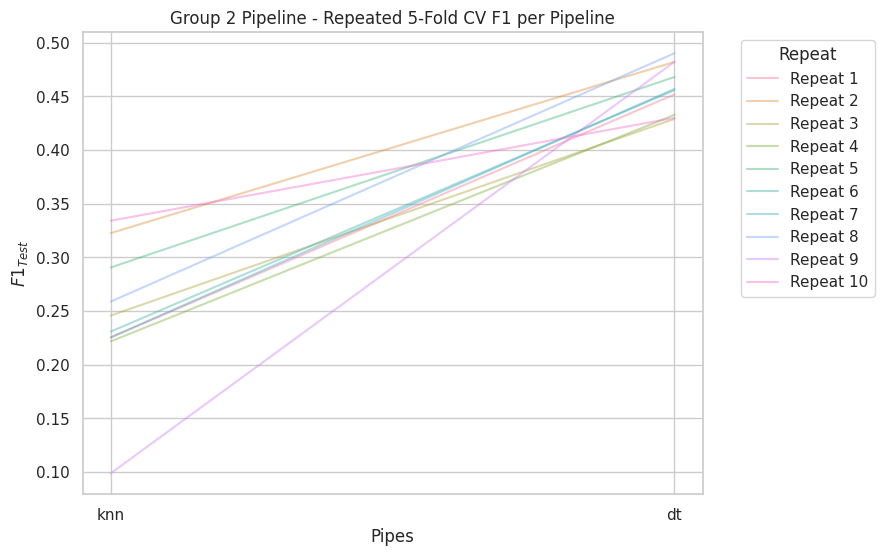

In [ ]:
df_long = results_g2.reset_index().melt(
    id_vars='index', var_name='pipe', value_name='f1'
)
df_long.rename(columns={'index': 'repeat'}, inplace=True)

plt.figure(figsize=(8,6))
sns.lineplot(
    data=df_long,
    x='pipe', y='f1',
    hue='repeat',
    estimator=None,
    alpha=0.4
)
plt.xlabel('Pipes')
plt.ylabel(r'$F1_{Test}$')
plt.title('Group 2 Pipeline - Repeated 5-Fold CV F1 per Pipeline')
plt.legend(title='Repeat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

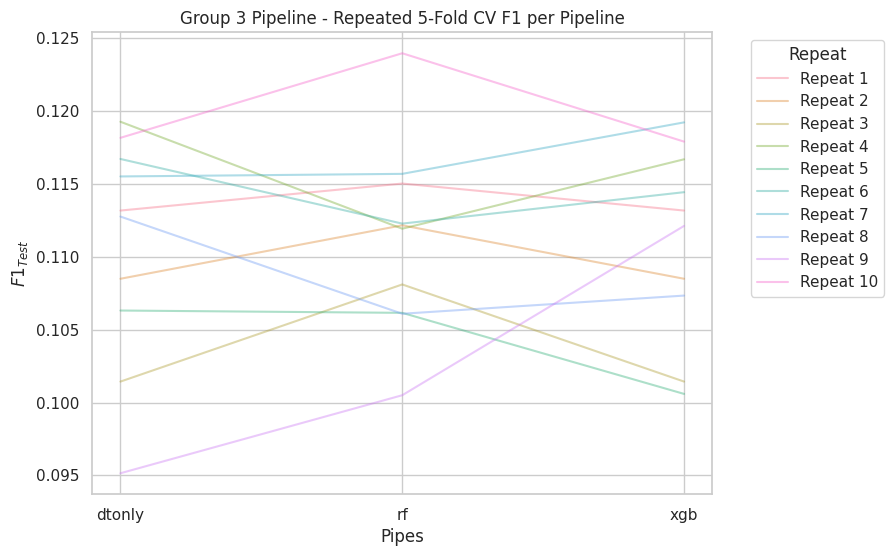

In [ ]:
df_long = results_g3.reset_index().melt(
    id_vars='index', var_name='pipe', value_name='f1'
)
df_long.rename(columns={'index': 'repeat'}, inplace=True)

plt.figure(figsize=(8,6))
sns.lineplot(
    data=df_long,
    x='pipe', y='f1',
    hue='repeat',
    estimator=None,
    alpha=0.4
)
plt.xlabel('Pipes')
plt.ylabel(r'$F1_{Test}$')
plt.title('Group 3 Pipeline - Repeated 5-Fold CV F1 per Pipeline')
plt.legend(title='Repeat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
cross_val_score(pipe5, X, y, cv=5, verbose=1, n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    2.7s finished


array([0.19083969, 0.51908397, 0.50763359, 0.20229008, 0.46360153])

In [ ]:
for p in pipes_lr:
  pipes_lr[p].fit(X_train,y_train)
  y_pred_p = pipes_lr[p].predict(X_test)
  print(f"----------- Results for {p} -----------")
  print(classification_report(y_test,y_pred_p))

----------- Results for standard -----------
              precision    recall  f1-score   support

           0       0.98      0.57      0.72       251
           1       0.07      0.73      0.12        11

    accuracy                           0.57       262
   macro avg       0.52      0.65      0.42       262
weighted avg       0.94      0.57      0.69       262

----------- Results for minmax -----------
              precision    recall  f1-score   support

           0       0.98      0.70      0.82       251
           1       0.10      0.73      0.17        11

    accuracy                           0.70       262
   macro avg       0.54      0.71      0.49       262
weighted avg       0.95      0.70      0.79       262

----------- Results for power -----------
              precision    recall  f1-score   support

           0       0.98      0.63      0.77       251
           1       0.07      0.64      0.13        11

    accuracy                           0.63       26

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


----------- Results for poly -----------
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       251
           1       0.38      0.82      0.51        11

    accuracy                           0.94       262
   macro avg       0.68      0.88      0.74       262
weighted avg       0.97      0.94      0.95       262

----------- Results for spline -----------
              precision    recall  f1-score   support

           0       0.99      0.73      0.84       251
           1       0.12      0.82      0.20        11

    accuracy                           0.73       262
   macro avg       0.55      0.77      0.52       262
weighted avg       0.95      0.73      0.81       262



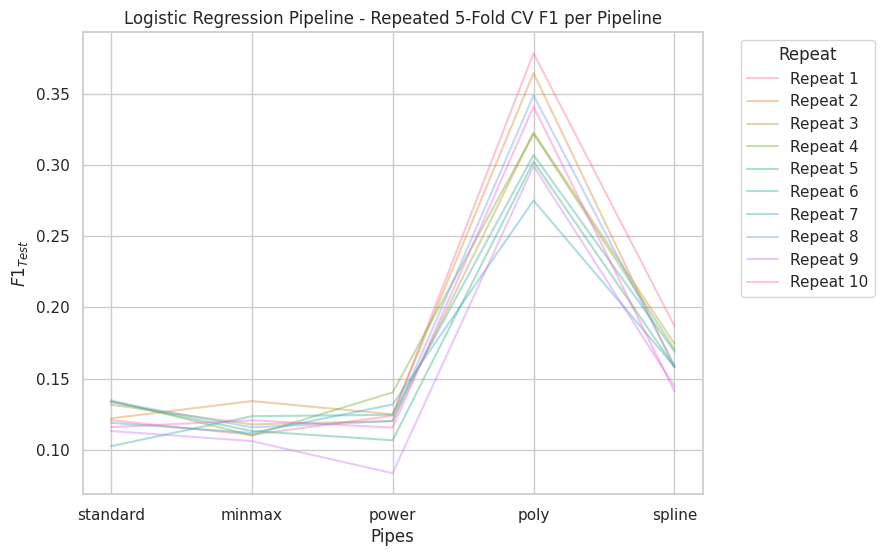

In [ ]:
df_long = results_g1.reset_index().melt(
    id_vars='index', var_name='pipe', value_name='f1'
)
df_long.rename(columns={'index': 'repeat'}, inplace=True)

plt.figure(figsize=(8,6))
sns.lineplot(
    data=df_long,
    x='pipe', y='f1',
    hue='repeat',
    estimator=None,
    alpha=0.4
)
plt.xlabel('Pipes')
plt.ylabel(r'$F1_{Test}$')
plt.title('Logistic Regression Pipeline - Repeated 5-Fold CV F1 per Pipeline')
plt.legend(title='Repeat', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [ ]:
cross_val_score(pipe4, X, y, cv=5, verbose=1, n_jobs=-1)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.3s finished


array([0.58396947, 0.47709924, 0.40458015, 0.46946565, 0.97318008])

In [ ]:
%%time
f1scores = []

for i in range(10):
    print(f"\nRepetition {i+1}")
    cv_logs = {}
    f1scores.append([])

    cv = KFold(n_splits=5, shuffle=True, random_state=i)

    for name, model in pipes.items():
        print(f"Running CV for: {name}")
        scores = cross_val_score(model, X, y, cv=cv, verbose=2, n_jobs=-1)
        cv_logs[name] = scores
        f1scores[i].append(scores.mean())

print("\nDone.")



Repetition 1
Running CV for: standard
Running CV for: minmax


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 2
Running CV for: standard
Running CV for: minmax


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   17.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 3
Running CV for: standard


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished


Running CV for: minmax
Running CV for: power


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   15.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 4
Running CV for: standard
Running CV for: minmax


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   15.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 5
Running CV for: standard
Running CV for: minmax


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   17.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 6
Running CV for: standard
Running CV for: minmax


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   17.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 7
Running CV for: standard
Running CV for: minmax


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 8
Running CV for: standard
Running CV for: minmax


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   17.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 9
Running CV for: standard
Running CV for: minmax


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 10
Running CV for: standard


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: minmax


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: power


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: spline

Done.
CPU times: user 1.91 s, sys: 249 ms, total: 2.16 s
Wall time: 2min 56s


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished


In [ ]:
cv_logs

{'poly': array([0.94656489, 0.89312977, 0.9389313 , 0.84732824, 0.78927203]),
 'knn': array([0.97328244, 0.96183206, 0.96946565, 0.9351145 , 0.94636015]),
 'dt': array([0.98091603, 0.95419847, 0.97328244, 0.93129771, 0.94252874]),
 'dtonly': array([0.96946565, 0.95801527, 0.96564885, 0.92366412, 0.9348659 ]),
 'rf': array([0.67175573, 0.60305344, 0.69847328, 0.6221374 , 0.55172414]),
 'xgb': array([0.96564885, 0.96946565, 0.96564885, 0.9351145 , 0.94636015])}

In [ ]:
np.array(f1scores).shape

(10, 5)

Text(0, 0.5, '$f1_{Test}$')

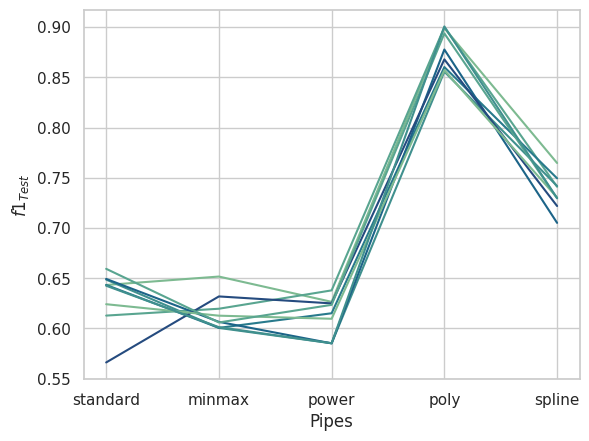

In [ ]:
for i in range(9):
  sns.lineplot(x=pipes.keys(),y=f1scores[i])
plt.xlabel('Pipes')
plt.ylabel('$f1_{Test}$')

In [ ]:
%%time
f1scores = []

for i in range(10):
    print(f"\nRepetition {i+1}")
    cv_logs = {}
    f1scores.append([])

    cv = KFold(n_splits=5, shuffle=True, random_state=i)

    for name, model in pipes2.items():
        print(f"Running CV for: {name}")
        scores = cross_val_score(model, X, y, cv=cv, verbose=2, n_jobs=-1)
        cv_logs[name] = scores
        f1scores[i].append(scores.mean())

print("\nDone.")



Repetition 1
Running CV for: poly


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   19.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly
Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 2
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   15.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly
Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 3
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly
Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 4
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 5
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly
Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 6
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   15.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly
Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 7
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 8
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   15.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly
Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 9
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly
Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



Repetition 10
Running CV for: poly


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   17.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: knn


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dt


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: dtonly
Running CV for: rf


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    1.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Running CV for: xgb

Done.
CPU times: user 3.84 s, sys: 309 ms, total: 4.14 s
Wall time: 3min 9s


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.4s finished


In [ ]:
models_old = [
    ('RandomForest', RandomForestClassifier(class_weight='balanced', random_state=42)),
    ('LogisticRegression', LogisticRegression(class_weight='balanced', max_iter=1000)),
    ('SVM', SVC(kernel='rbf', class_weight='balanced', probability=True)),
    ('MLP', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)),
    ('XGBoost', XGBClassifier(
        scale_pos_weight=20,   # for class imbalance
        eval_metric='logloss',
        use_label_encoder=False
    ))
]

Text(0, 0.5, '$f1_{Test}$')

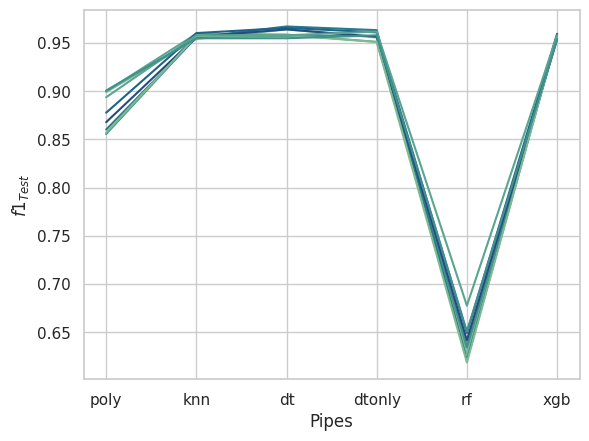

In [ ]:
for i in range(9):
  sns.lineplot(x=pipes2.keys(),y=f1scores[i])
plt.xlabel('Pipes')
plt.ylabel('$f1_{Test}$')

In [ ]:
cv_logs

{'poly': array([0.94656489, 0.89312977, 0.9389313 , 0.84732824, 0.78927203]),
 'knn': array([0.97328244, 0.96183206, 0.96946565, 0.9351145 , 0.94636015]),
 'dt': array([0.98091603, 0.95419847, 0.97328244, 0.93129771, 0.94252874]),
 'dtonly': array([0.96946565, 0.95801527, 0.96564885, 0.92366412, 0.9348659 ]),
 'rf': array([0.67175573, 0.60305344, 0.69847328, 0.6221374 , 0.55172414]),
 'xgb': array([0.96564885, 0.96946565, 0.96564885, 0.9351145 , 0.94636015])}

Trying

In [ ]:
models = [
    ('LogisticRegression', LogisticRegression(class_weight='balanced', max_iter=1000))
    ('LogisticRegression', LogisticRegression(class_weight='balanced', max_iter=1000)),
    ('SVM', SVC(kernel='rbf', class_weight='balanced', probability=True)),
    ('MLP', MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500)),
    ('XGBoost', XGBClassifier(
        scale_pos_weight=20,   # for class imbalance
        eval_metric='logloss',
        use_label_encoder=False
    ))
]

In [ ]:
preprocessors = [
    ('SS', preprocess_ss),
    ('MM', preprocess_mm),
    ('PF', preprocess_pf),
    ('ST', preprocess_st)
]


Model: poly (lr)
Accuracy: 0.9351145038167938
F1 Score: 0.5142857142857142
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       251
           1       0.38      0.82      0.51        11

    accuracy                           0.94       262
   macro avg       0.68      0.88      0.74       262
weighted avg       0.97      0.94      0.95       262

------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


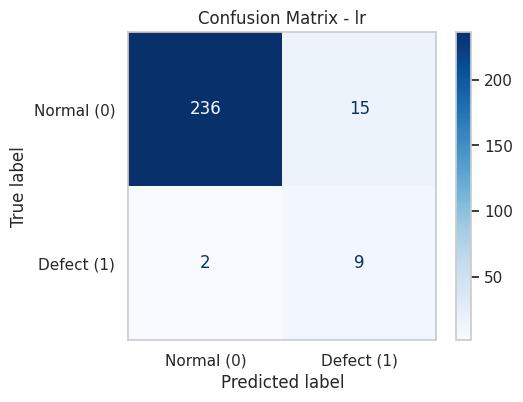

----------------------------------------

Model: knn (lr)
Accuracy: 0.9618320610687023
F1 Score: 0.2857142857142857
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       251
           1       0.67      0.18      0.29        11

    accuracy                           0.96       262
   macro avg       0.82      0.59      0.63       262
weighted avg       0.95      0.96      0.95       262

------------------------------------


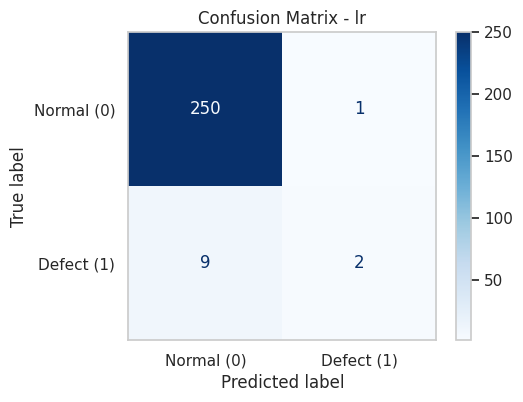

----------------------------------------

Model: dt (dt)
Accuracy: 0.9732824427480916
F1 Score: 0.5333333333333333
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       251
           1       1.00      0.36      0.53        11

    accuracy                           0.97       262
   macro avg       0.99      0.68      0.76       262
weighted avg       0.97      0.97      0.97       262

------------------------------------


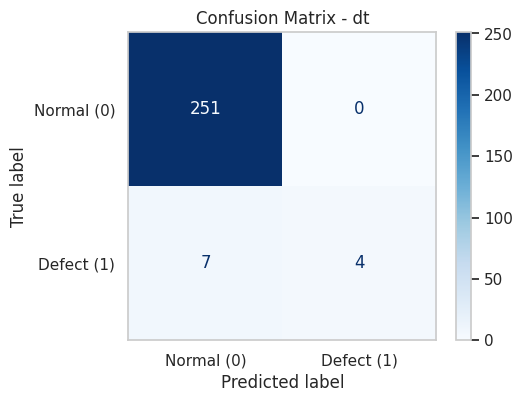

----------------------------------------

Model: dtonly (dt2)
Accuracy: 0.9541984732824428
F1 Score: 0.45454545454545453
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       251
           1       0.45      0.45      0.45        11

    accuracy                           0.95       262
   macro avg       0.72      0.72      0.72       262
weighted avg       0.95      0.95      0.95       262

------------------------------------


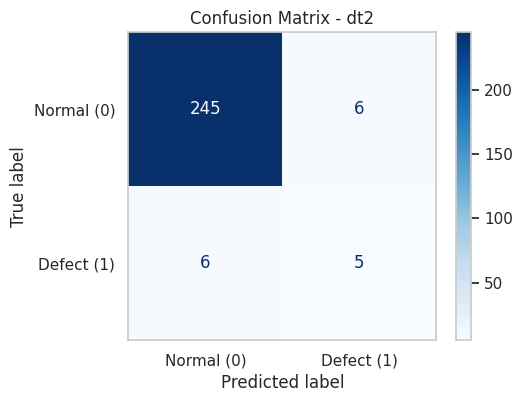

----------------------------------------

Model: rf (rf)
Accuracy: 0.6183206106870229
F1 Score: 0.13793103448275862
              precision    recall  f1-score   support

           0       0.98      0.61      0.75       251
           1       0.08      0.73      0.14        11

    accuracy                           0.62       262
   macro avg       0.53      0.67      0.45       262
weighted avg       0.94      0.62      0.73       262

------------------------------------


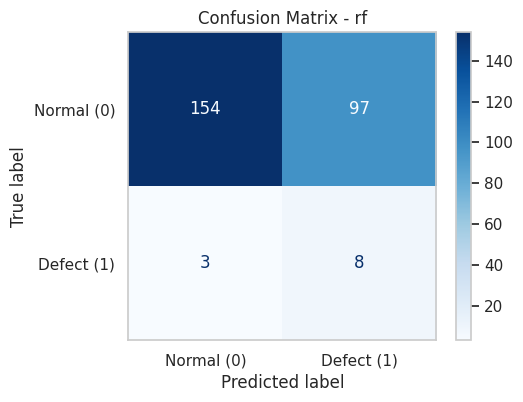

----------------------------------------

Model: xgb (xgb)
Accuracy: 0.9732824427480916
F1 Score: 0.631578947368421
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       251
           1       0.75      0.55      0.63        11

    accuracy                           0.97       262
   macro avg       0.87      0.77      0.81       262
weighted avg       0.97      0.97      0.97       262

------------------------------------


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [19:05:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


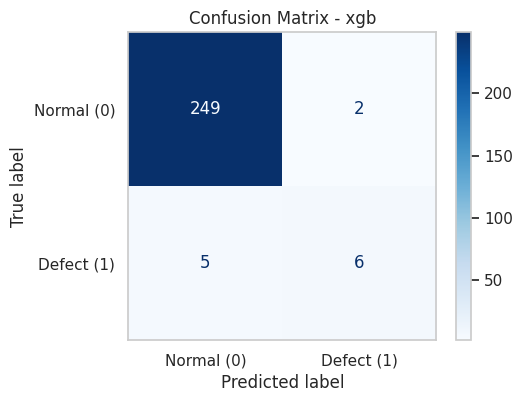

----------------------------------------


In [ ]:
for pipe_name, pipe in pipes2.items():
    evaluate_model(
        pipe_name,
        pipe,
        X_train,
        X_test,
        y_train,
        y_test
    )